In [1]:
import os
import os.path as op

import importlib

import numpy as np
import pandas as pd

import nibabel as nib
from nilearn import datasets, image

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpecFromSubplotSpec

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from scipy.stats import spearmanr

from seaborn import kdeplot

from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import networkx as nx

import h5py

import dgsp
import bimod_plots as plot
import palettes

import data_load as dload
import bundle as b_utils

dict_keys(['cluster_palette', 'cluster_palette_cb', 'cluster_palette_soft', 'div_rb', 'extended_ncar'])


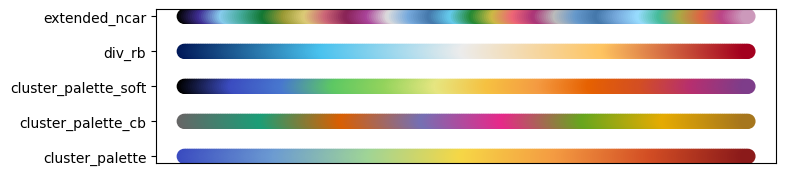

In [2]:
importlib.reload(palettes)
importlib.reload(plot)

cmaps = plot.get_all_cmaps()
print(cmaps.keys())

In [3]:
import sys
path_to_effective = "../../effectivedelay_estimation"
sys.path.append(path_to_effective)

from src import regmod
from src import utils
from src import solver

path_to_ressources = op.join(path_to_effective, "resources")
path_to_data = "/Users/acionca/data"
path_to_ec = "./results/atlas_correspondence"

path_to_mstruct = "/Users/acionca/data/microstructure_connectomes_HCP_3T"
path_to_lobe = "./results/atlas_correspondence"

path_to_benchmark = "/Users/acionca/code/dGSP/dSVD/results/BrainKmeans"

There are 141 nodes in the graph
54.08% of connections remain  after thresholding


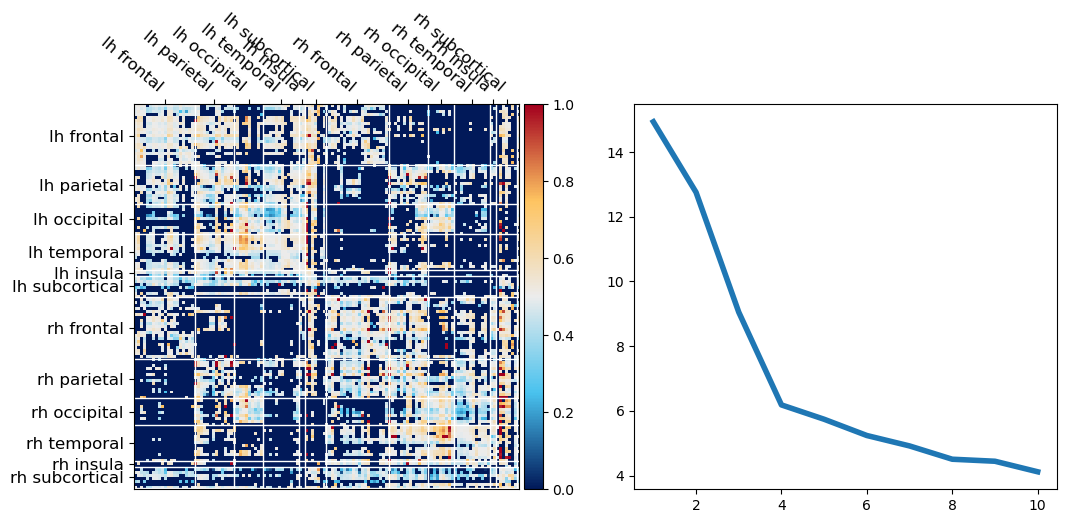

In [4]:
importlib.reload(dload)
importlib.reload(dgsp)
importlib.reload(b_utils)
importlib.reload(plot)

all_scales = [1, 2, 3, 4]

use_delay = False
k_threshold = 0
b_thresh = 0
slines_theshold = 5

struct_type = ""

scale = 2

k_matrix, labels, node_centers = dload.load_bundle_graph(path_to_data=path_to_ressources,
                                                         data_suffix="Laus2018_",
                                                         scale=scale,
                                                         b_prob_threshold=0,
                                                         slines_theshold=slines_theshold,
                                                         log_slines=False,
                                                         normalize_slines=False,
                                                         verbose=True)

labels, k_matrix = b_utils.fix_thalamus(labels, matrix=k_matrix)
k_matrix[k_matrix < b_thresh] = 0

# ec_data = dload.load(op.join(path_to_ec, f"Laus2018_EffConnFromSch414-scale{scale}.pkl"))
# ec_data = dload.load(op.join(path_to_ec, f"Laus2018_EffConnFromSch414-scale{scale}OneThal.pkl"))
# ec_mat = ec_data["conv"]
# # print(f"Removing {np.sum(ec_mat < 0)/ec_mat.size*100:.2f}% negative weights from EC matrix")
# ec_mat[ec_mat < 0] = 0

ec_mat = dload.get_ec_data(scale=scale, path_to_ec=path_to_ec, remove_neg=True, fix_thal=True)

# labels = b_utils.fix_thalamus(labels, matrix=None)

gamma = 1
ec_mat = ec_mat ** gamma
dir_ratio = np.divide(ec_mat, (ec_mat + ec_mat.T),
                      where=(ec_mat + ec_mat.T) > 0,
                      out=np.zeros_like(ec_mat))
graph = (k_matrix > 0) * dir_ratio

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph))
V = Vh.T

n_nodes = len(S)

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

order_by_lobe, lobe_sizes, lobe_labels, lobe_df = dload.get_lobe_info(scale, labels, path_to_lobe=path_to_lobe)

axes[0].imshow(graph[order_by_lobe][:, order_by_lobe], cmap=cmaps["div_rb"], interpolation="none")
plot.add_cbar(fig ,axes[0])
plot.plot_lobe_lines(axes[0], lobe_sizes, lobe_labels)

nshow = 10
axes[1].plot(np.arange(nshow)+1, S[:nshow], lw=4, zorder=0)

## Consensus Clustering

In [5]:
importlib.reload(dgsp)

scale = 2
gamma = 2
n_vec_max = 20
# n_vec_max = 5
scale_factor = S[:n_vec_max] ** 2

n_trials = 50
n_init = 50
dthresh = 0
selected_sort = 0

# all_n_kmeans = np.arange(10, 250, 5)
# all_n_kmeans = np.arange(10, 100, 1)
all_n_kmeans = np.arange(10, 80, 1)

bm_fname = "_".join([
    f"brain_consensus-EC",
    f"scale{scale}",
    f"nvec{n_vec_max}",
    f"trials{n_trials}",
    f"ninit{n_init}",
    f"kmeans{all_n_kmeans[0]}-{all_n_kmeans[-1]}",
    f"slines_thresh{slines_theshold}",
    f"ustruct{struct_type}"*(struct_type != ""),
    f"dthresh{dthresh}"*(dthresh != 0),
    f"gamma{gamma}"*(gamma != 1),
    f"selected{selected_sort}"*(selected_sort != 0)
    ])
bm_fname += ".pkl"

if op.isfile(op.join(path_to_benchmark, bm_fname)):
    data = dload.load(op.join(path_to_benchmark, bm_fname))
    graph = data["graph"]
    all_n_kmeans = data["all_n_kmeans"]
    cons_lab = data["cons_lab"]
    cons_lab_fix = data["cons_lab_fix"]
    all_c_within = data["all_c_within"]
    all_c_between = data["all_c_between"]
    all_c_within_fix = data["all_c_within_fix"]
    all_c_between_fix = data["all_c_between_fix"]
    avg_cons = data["avg_cons"]
    avg_cons_fix = data["avg_cons_fix"]
else:
    print("No benchmark file found - Run the benchmarking script.")
    print(f"\t`{bm_fname}`")

path_to_figures = op.join(path_to_benchmark, "figures", f"scale{scale}")
os.makedirs(path_to_figures, exist_ok=True)
fig_suffix = f"_gamma{gamma}_nvec{n_vec_max}"

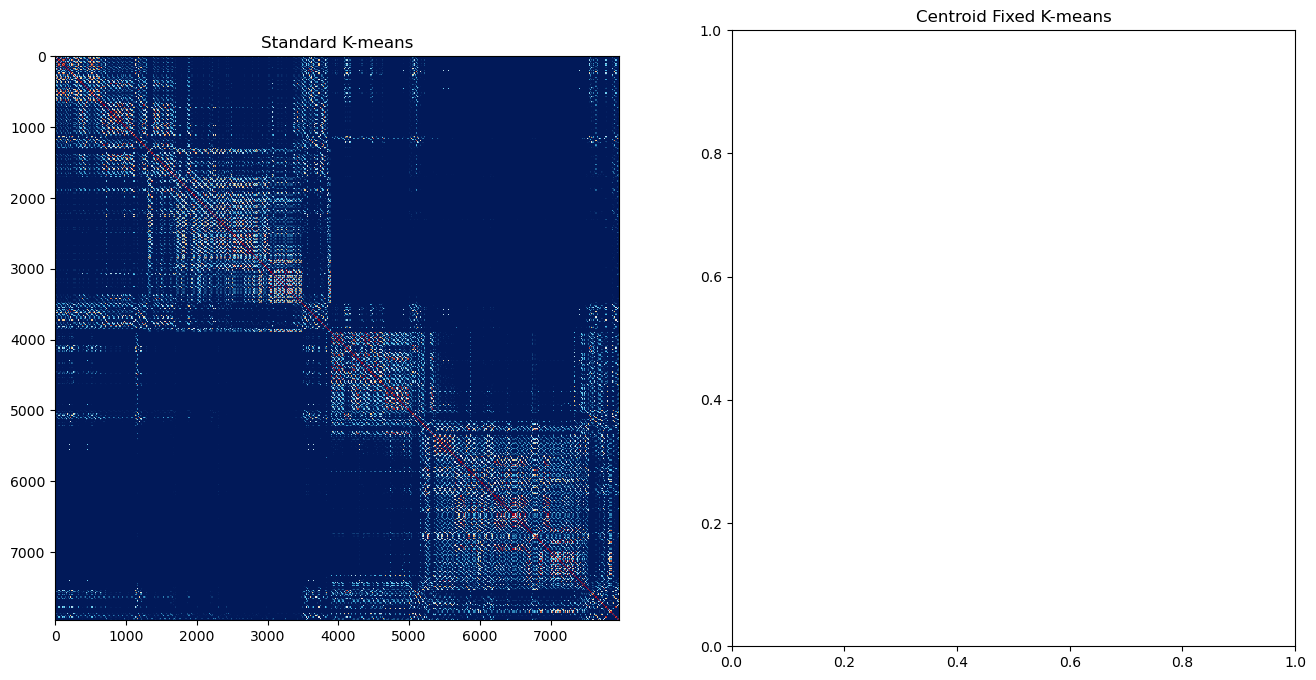

In [6]:
fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

axes[0].set_title("Standard K-means")
axes[0].imshow(avg_cons, cmap=cmaps["div_rb"],
               vmin=0, vmax=1,
               interpolation="none")

axes[1].set_title("Centroid Fixed K-means")
if avg_cons_fix is not None:
    axes[1].imshow(avg_cons_fix, cmap=cmaps["div_rb"],
                vmin=0, vmax=1,
                interpolation="none")

## Looking at Dendrogram

In [7]:
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    return dendrogram(linkage_matrix, **kwargs)

print(avg_cons.shape)
# print(avg_cons_fix.shape)

hierarchical_matrix = 1 - avg_cons
# hierarchical_matrix = 1 - avg_cons_fix
c_mat = 1 - hierarchical_matrix

(7963, 7963)


In [8]:
# model = AgglomerativeClustering(distance_threshold=0.5, n_clusters=None, metric="precomputed", linkage="average", compute_distances=True)
# model = model.fit(hierarchical_matrix)

# # model.distances_ gives the linkage distances
# distances = np.flip(model.distances_)
# diff_dist = -np.diff(distances)

dist_condensed = squareform(hierarchical_matrix)
Z = linkage(dist_condensed, method='average', metric='precomputed')
distances = np.flip(Z[:, 2])
diff_dist = -np.diff(distances)

<Axes: ylabel='Density'>

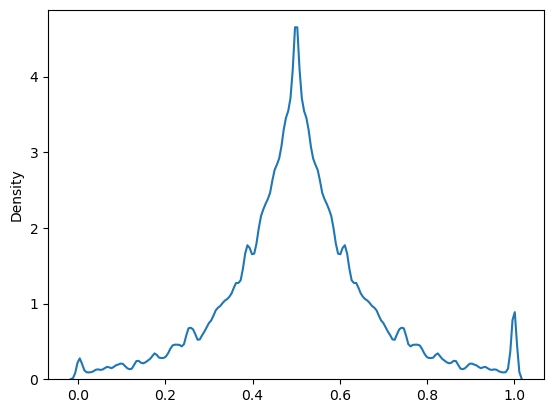

In [9]:
kdeplot(graph[graph > 0], bw_adjust=0.2)

Oopsie
Best k is at max diff: 12 with distance jump 0.0320
Top 10 largest jumps in distance:
 -10: K = 10,	dist: 0.0117, 	cut: 0.9653
 -09: K = 40,	dist: 0.0117, 	cut: 0.7252
 -08: K = 32,	dist: 0.0119, 	cut: 0.7810
 -07: K = 35,	dist: 0.0121, 	cut: 0.7444
 -06: K = 65,	dist: 0.0127, 	cut: 0.5997
 -05: K = 33,	dist: 0.0142, 	cut: 0.7692
 -04: K = 18,	dist: 0.0158, 	cut: 0.9013
 -03: K = 44,	dist: 0.0250, 	cut: 0.7058
 -02: K = 23,	dist: 0.0282, 	cut: 0.8508
 -01: K = 13,	dist: 0.0320, 	cut: 0.9486


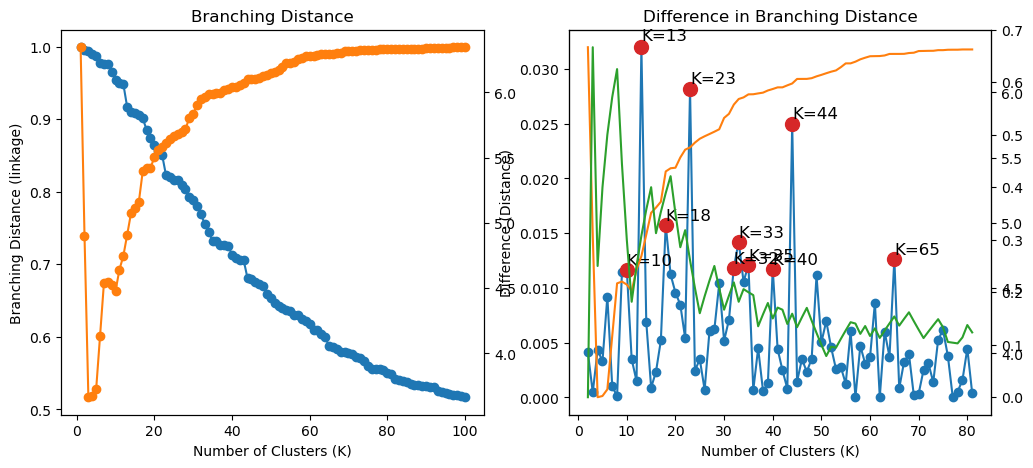

In [10]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

n_samples = len(hierarchical_matrix)

# Number of clusters K decreases from n_samples to 1
n_clusters = np.arange(1, n_samples)

# Scale 3 took 1 min for 50 iterations
nshow = 100 #200

# precompute pair indices for condensed vector
p_idx, q_idx = np.triu_indices(n_samples, k=1)

all_ratios = np.zeros(nshow)
all_self = np.zeros(nshow)
all_bi = np.zeros(nshow)
for i, k in enumerate(n_clusters[:nshow]):
    labs = fcluster(Z, t=k, criterion='maxclust')

    pair_same = (labs[p_idx] == labs[q_idx])
    within_val = 1 - dist_condensed[pair_same]
    between_val = 1 - dist_condensed[~pair_same]

    within_mean = within_val[within_val > 0].mean()
    if len(between_val[between_val > 0]) == 0:
        print("Oopsie")
        all_ratios[i] = np.nan
        continue
    else:
        between_mean = between_val[between_val > 0].mean()

    all_ratios[i] = within_mean / between_mean

    e_labels = labs
    e_mat = np.zeros_like(graph, dtype=int)
    e_mat[graph > 0] = e_labels

    send, rec = dgsp.get_node_clusters(e_labels, e_mat)
    row_ind, col_ind = dgsp.get_conjugates_matching(send, rec)

    self = np.where(row_ind == col_ind)[0]
    all_self[i] = len(self)

all_ratios = np.nan_to_num(all_ratios, nan=np.nanmax(all_ratios))

best_k = np.argmax(diff_dist)+1
print(f"Best k is at max diff: {best_k} with distance jump {diff_dist[best_k-1]:.4f}")
# nshow= np.ceil(best_k/10).astype(int)*10

# Plot branching distance vs number of clusters
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
axes[0].plot(n_clusters[:nshow], distances[:nshow], marker='o', zorder=1)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Branching Distance (linkage)")
axes[0].set_title("Branching Distance")

ax2 = axes[0].twinx()
ax2.plot(n_clusters[:nshow], all_ratios[:nshow], marker='o', color="tab:orange", zorder=0)

nplots = np.min([nshow, 80])
axes[1].plot(n_clusters[:nplots]+1, diff_dist[:nplots], marker='o', zorder=1)
ax22 = axes[1].twinx()
ax22.plot(n_clusters[:nplots]+1, all_ratios[:nplots], color="tab:orange", zorder=0)

ax33 = axes[1].twinx()
ax33.plot(n_clusters[:nplots]+1, all_self[:nplots]/(n_clusters[:nplots]+1), color="tab:green", zorder=0)

axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Difference (Distance)")
axes[1].set_title("Difference in Branching Distance")

print("Top 10 largest jumps in distance:")
for i, top10 in enumerate(np.argsort(diff_dist)[-10:]):
    print(f" -{10-i:02d}: K = {top10+2},\tdist: {diff_dist[top10]:.4f}, \tcut: {distances[top10]:.4f}")

    axes[1].scatter(n_clusters[top10]+1, diff_dist[top10], marker='o', color="tab:red", s=100)
    axes[1].text(n_clusters[top10]+1, diff_dist[top10]*1.01, f"K={top10+2}", fontsize=12,
                 ha='left', va='bottom')

In [11]:
# mysort = np.flip(np.argsort(diff_dist))

# fig, axes = plt.subplots()
# # plt.plot(diff_dist[mysort], marker='o')
# axes.plot(mysort + 2, diff_dist[mysort], marker='o')

# axes.set_xlim(-1, 200)

# for thresh in np.logspace(-3, -2, 10):
#     print(f"{thresh:0.4f}: {sum(diff_dist > thresh)} over {len(diff_dist)}")
#     axes.axhline(thresh, color="gray", lw=1, ls=':')

In [12]:
cmaps

{'cluster_palette': <matplotlib.colors.LinearSegmentedColormap at 0x30e8ed490>,
 'cluster_palette_cb': <matplotlib.colors.LinearSegmentedColormap at 0x32a02af50>,
 'cluster_palette_soft': <matplotlib.colors.LinearSegmentedColormap at 0x32a031610>,
 'div_rb': <matplotlib.colors.LinearSegmentedColormap at 0x32a031810>,
 'extended_ncar': <matplotlib.colors.LinearSegmentedColormap at 0x32a03db90>}

1 31


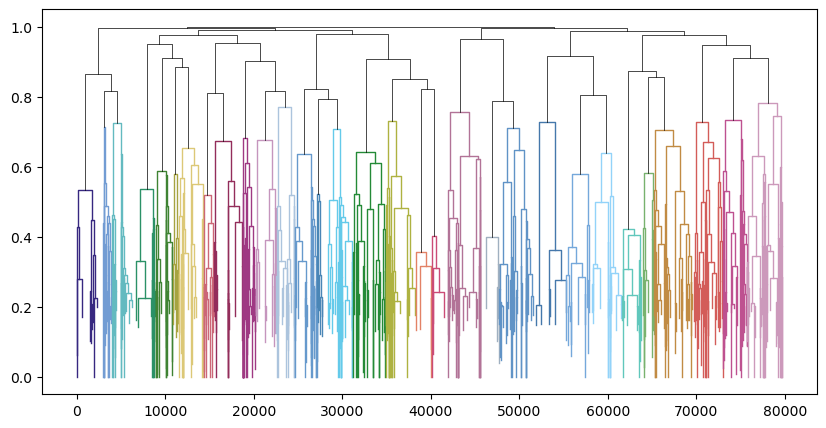

In [13]:
def styled_dendrogram(Z, k=None, cut_height=None, top_color="k", cmap=None, p=0, lw=2, dyn_lw=True, line_styles=None, ax=None, **kwargs):
    """
    Draw a dendrogram with custom per-branch style.
    line_styles: list of dicts, same length as number of merges.
    Each dict can have keys like 'color', 'linewidth', 'linestyle'.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    d = dendrogram(Z, no_plot=True, **kwargs)
    n_leaves = len(d['leaves'])

    ordered_labs = None
    if k is not None:
        labs = fcluster(Z, t=k, criterion='maxclust')
        ordered_labs = labs[d['leaves']]
    elif cut_height is not None:
        labs = fcluster(Z, t=cut_height, criterion='distance')
        ordered_labs = labs[d['leaves']]
    
    print(labs.min(), labs.max())
    
    if cmap is None:
        cmap = plt.get_cmap('tab20')

    cluster_colors = {}
    if ordered_labs is not None:
        uniq = np.unique(ordered_labs)
        if len(uniq) == 1:
            cluster_colors[uniq[0]] = cmap(1)
        else:
            for i, u in enumerate(uniq):
                # cluster_colors[u] = cmap(i / (len(uniq) - 1))
                cluster_colors[u] = cmap((i + 1) / (len(uniq)))
    
    for i, (xs, ys) in enumerate(zip(d['icoord'], d['dcoord'])):
        height = max(ys)

        if height < p:
            continue
        # height = min(ys)
        if (cut_height is not None) and (height > cut_height):
            color = top_color
            l_lw = lw/2 if dyn_lw else lw
        elif ordered_labs is None:
            # fallback to provided style or black
            color = (line_styles[i].get('color') if line_styles and i < len(line_styles) and 'color' in line_styles[i]
                     else 'k')
        else:
            # map branch x-range to leaf index range in the leaf order
            left_x, right_x = min(xs), max(xs)
            left_idx = int(np.clip(np.floor((left_x - 5) / 10 + 1e-9), 0, n_leaves - 1))
            right_idx = int(np.clip(np.ceil((right_x - 5) / 10 - 1e-9), 0, n_leaves - 1))
            branch_labels = ordered_labs[left_idx:(right_idx + 1)]
            # choose majority cluster for that branch
            vals, counts = np.unique(branch_labels, return_counts=True)
            maj = vals[np.argmax(counts)]
            color = cluster_colors.get(maj, top_color)
            l_lw = lw

        style = line_styles[i] if line_styles and i < len(line_styles) else {}
        # ensure we don't pass 'color' from style (we override it)
        style = {k: v for k, v in style.items() if k != 'color'}
        ax.plot(xs, ys, color=color, lw=l_lw, **style)

    return d, ax

# cmap_dendro = cmaps["extended_ncar"].resampled(len(Z))
# ls_list = [{"lw": 1, "color": cmap_dendro(i)} for i in range(len(Z))]
ls_list = [{"lw": 0.5}]*len(Z)
_ = styled_dendrogram(Z, color_threshold=0.5, cut_height=0.7831, p=0.2, line_styles=None, lw=1, cmap=cmaps["extended_ncar"])

1 23
1 13
0 13
1 23
0 23
1 44
0 44


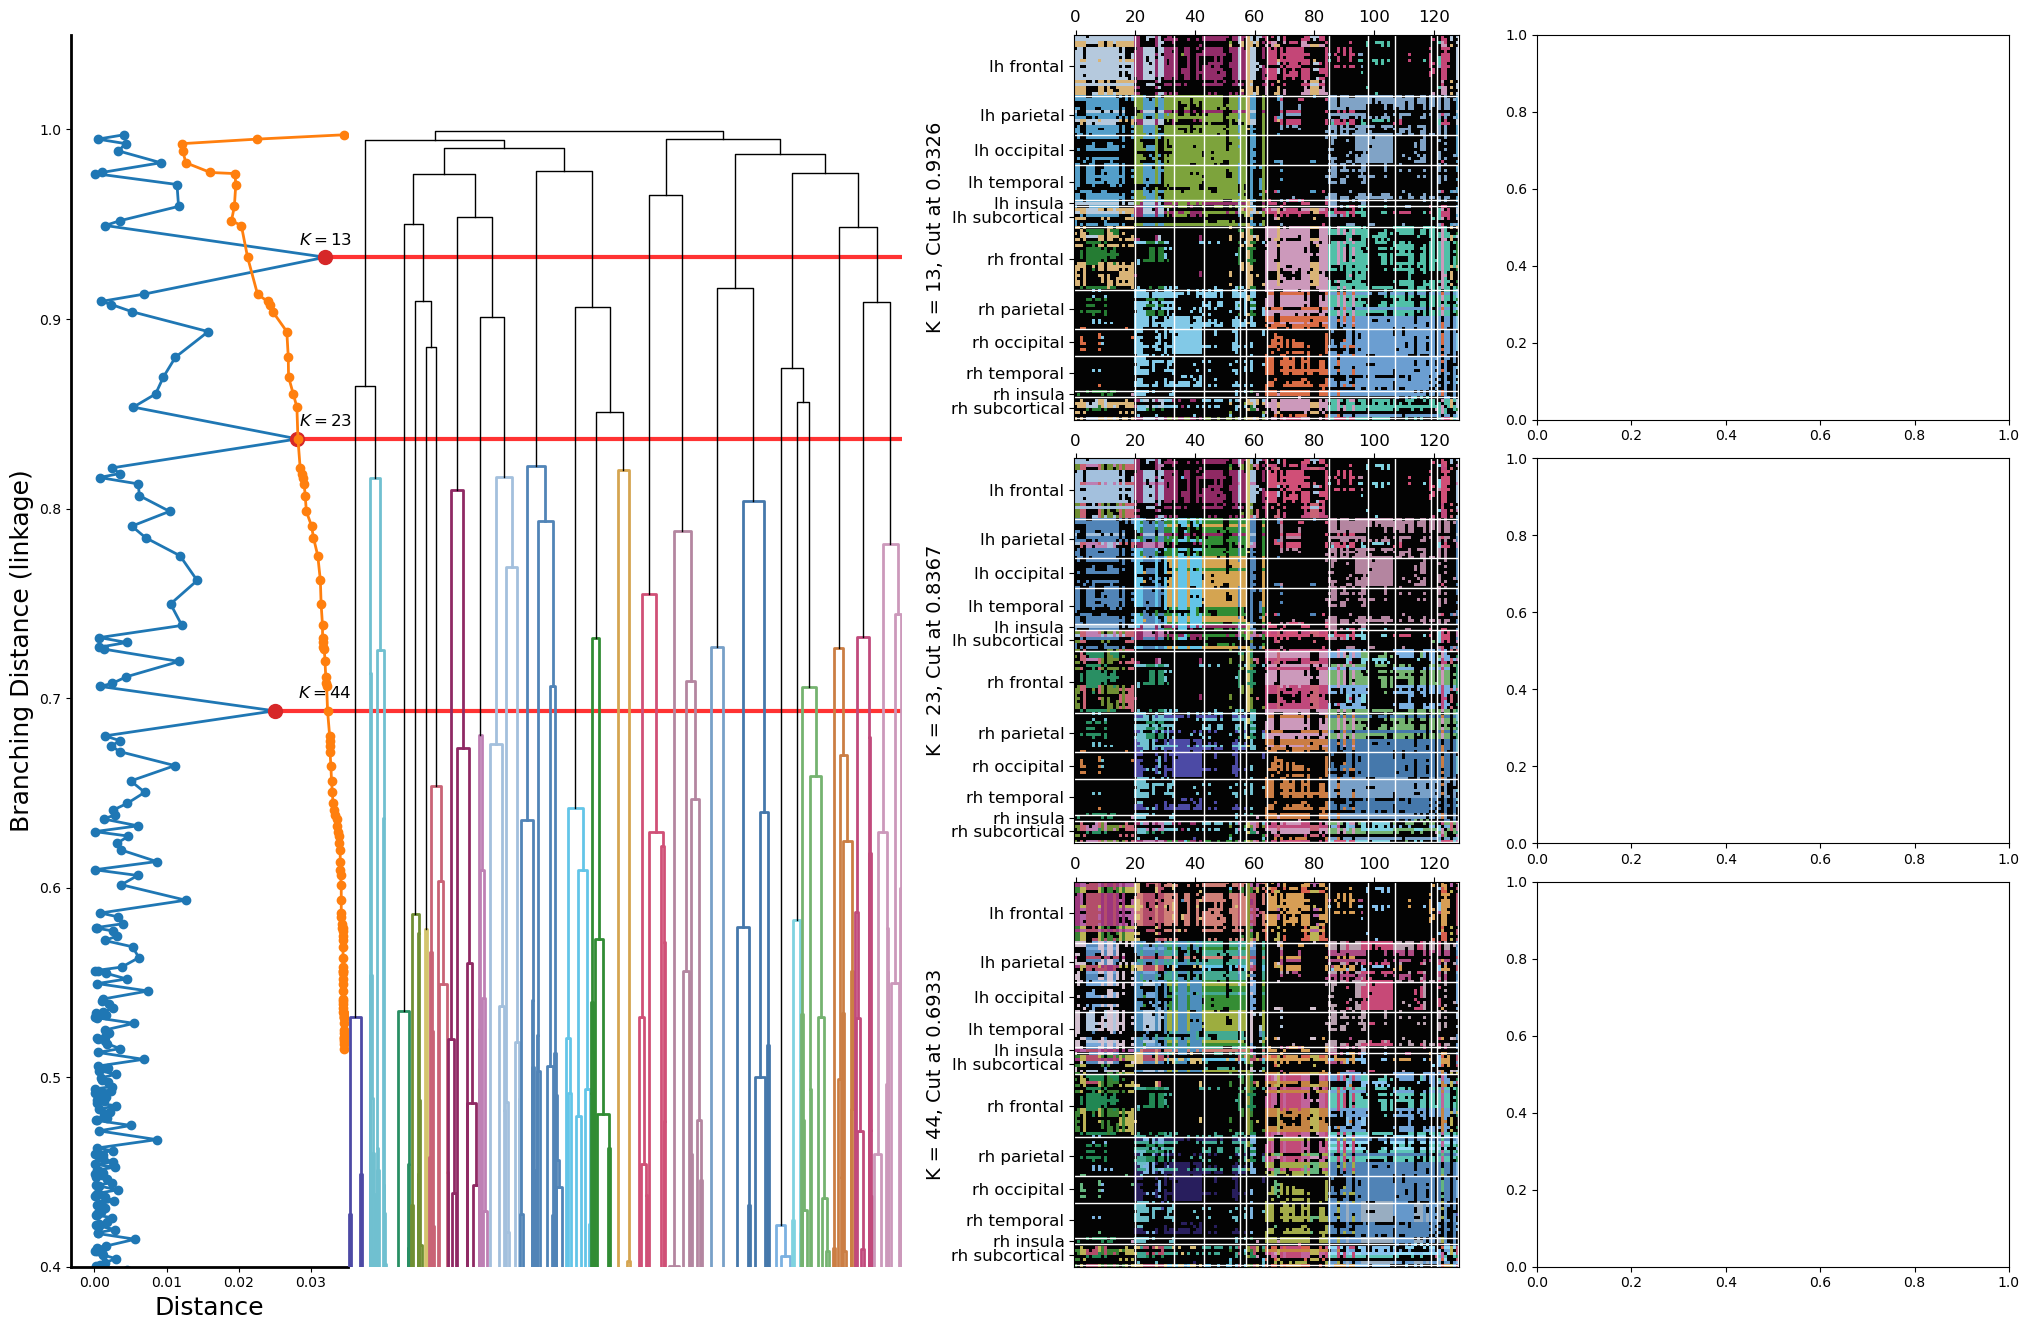

In [14]:
importlib.reload(dgsp)
importlib.reload(plot)

fig, axes = plt.subplots(ncols=3, figsize=(25, 16), gridspec_kw={'wspace': 0, "width_ratios":[0.5, 1, 2]},
                         sharey=True)

cut_dist = distances[:-1] - diff_dist/2
axes[0].plot(diff_dist, cut_dist, marker='o', lw=2)

ax_cons = axes[0].twiny()
all_r_plot = all_ratios/np.nanmax(all_ratios)
ax_cons.plot(all_r_plot, cut_dist[:len(all_ratios)], marker='o', lw=2,
             color="tab:orange", zorder=3)

# ax_cons.set_xlim(0.65, 1.01)
# ax_cons.set_xlim(0, 1.01)
ax_cons.set_xlim(all_r_plot.min()/2, 1.01)
ax_cons.axis("off")

best_show = 4
selected_list = [-1, -2, -4]
selected_list = [-1, -2, -3]
# selected_list = [-1, -2, -3]
# selected_list = [-1, -3, -8]
# print(n_clusters[np.argsort(all_ratios)[-20:]] + 1)

best10_list = np.argsort(diff_dist)[selected_list]
for i, top10 in enumerate(best10_list):

    axes[0].scatter(diff_dist[top10], cut_dist[top10], marker='o', color="tab:red", s=100, zorder=2)
    axes[0].text(diff_dist.max(), cut_dist[top10]+5e-3, f"$K={top10+2}$", fontsize=12,
                 ha='center', va='bottom')
    
    axes[0].plot([diff_dist[top10], 0.1], [cut_dist[top10]]*2, color="r", lw=3, alpha=0.8, zorder=0)
    axes[1].axhline(cut_dist[top10], color="r", lw=3, alpha=0.8)

cut_thresh = 0.77
cut_thresh = cut_dist[best10_list[-1]]
cut_thresh = cut_dist[best10_list[-2]]

axes[0].set_xlabel("Distance", fontsize=18)
axes[0].set_ylabel("Branching Distance (linkage)", fontsize=18)

axes[0].spines[["top", "right"]].set_visible(False)
axes[0].spines[:].set_linewidth(2)
axes[0].set_xlim(-diff_dist.max()*0.1, diff_dist.max()*1.1)

axes[1].axis("off")

e_labels = fcluster(Z, t=cut_thresh, criterion='distance')
k = e_labels.max()
ls_list = [{"lw": 1}]*len(Z)
cluster_cmap = cmaps["extended_ncar"].resampled(k+1)
d_dict, axes[1] = styled_dendrogram(Z, color_threshold=0.5, cut_height=cut_thresh, lw=2, cmap=cluster_cmap, ax=axes[1])

axes[1].set_xlim(-100, np.max(d_dict["icoord"]) + 100)
axes[1].set_ylim(0.4, 1.05)

# selected_cuts = np.flip(sorted(cut_dist[best10_list[-best_show:]]))
selected_cuts = np.flip(sorted(cut_dist[best10_list]))
# selected_cuts = np.concatenate([[0.999], selected_cuts])

axes[2].axis("off")
gs = GridSpecFromSubplotSpec(len(selected_cuts), 1, subplot_spec=axes[2].get_subplotspec(), hspace=0.1)
axes_bicom = [fig.add_subplot(gs[i]) for i in range(len(selected_cuts))]

all_e_labels = []
all_e_mats = []
all_send_rec = []
all_conj = []
all_ks = []
all_dist = []
for i, axes_bc in enumerate(axes_bicom):
    axes_bc.axis("off")
    gs = GridSpecFromSubplotSpec(1, 3, subplot_spec=axes_bc.get_subplotspec(), wspace=0.1, width_ratios=[0.2, 1, 1])
    ax_bc = [fig.add_subplot(gs[i]) for i in range(3)]
    # ax_bc[0].axis("off")

    e_labels = fcluster(Z, t=selected_cuts[i], criterion='distance')
    print(e_labels.min(), e_labels.max())
    e_mat = np.zeros_like(graph, dtype=int)
    e_mat[graph != 0] = e_labels
    print(e_mat.min(), e_mat.max())

    send, rec = dgsp.get_node_clusters(e_labels, e_mat)
    # bimod_idx = dgsp.bimod_index_nodes(graph, send, rec, scale=True)
    # sorting_array = np.flip(np.argsort(bimod_idx))

    # edge_clusters_mat_sorted = e_mat.copy()
    # edge_clusters_sorted = e_labels.copy()
    # for i_new, k in enumerate(sorting_array):
    #     edge_clusters_mat_sorted[e_mat == k + 1] = i_new + 1
    #     edge_clusters_sorted[e_labels == k + 1] = i_new + 1

    # e_mat = edge_clusters_mat_sorted
    # e_labels = edge_clusters_sorted

    # send = send[sorting_array]
    # rec = rec[sorting_array]

    all_e_labels.append(e_labels)
    all_e_mats.append(e_mat)
    all_send_rec.append((send, rec))
    # all_conj.append(dgsp.get_conjugates_matching(send, rec))

    ax_bc[0].axis("off")
    # ax_bc[1].axis("off")
    # ax_bc[2].imshow(e_mat, cmap=cluster_cmap, vmin=0, vmax=len(np.unique(e_labels))+1, interpolation="none")
    cluster_cmap = cmaps["cluster_palette_soft"]
    cluster_cmap = cmaps["extended_ncar"].resampled(e_labels.max()+1)
    ax_bc[1].imshow(e_mat[order_by_lobe][:, order_by_lobe], cmap=cluster_cmap, vmin=0, vmax=len(np.unique(e_labels))+1, interpolation="none")
    plot.plot_lobe_lines(ax_bc[1], lobe_sizes, lobe_labels, y_only=True)
    ax_bc[1].set_ylabel(f"K = {e_mat.max()}, Cut at {selected_cuts[i]:.4f}", fontsize=14)

    sort_lab = np.argsort(e_labels)
    c_mat = 1 - hierarchical_matrix
    
    # diag_mask = model_plot.labels_[:, None] == model_plot.labels_[None, :]
    # n_diag_mask = ~diag_mask

    # within_val = c_mat[diag_mask]
    # between_val = c_mat[n_diag_mask]

    # # within_mean = within_val[within_val > 0].mean()
    # # between_mean = between_val[between_val > 0].mean()
    # within_mean = within_val.mean()
    # between_mean = between_val.mean()

    # print("Within:", within_mean, "Outside:", between_mean)
    # print("Ratio:", within_mean / max([between_mean, 1e-10]))

    # ax_bc[2].imshow(c_mat[sort_lab][:, sort_lab], cmap="magma", vmin=0, vmax=1, interpolation="none")
    # ax_bc[2].axis("off")
    
    # ax_bc[1].set_ylabel(f"K = {e_mat.max()}, Cut at {selected_cuts[i]:.4f}", fontsize=14)
    # ax_bc[1].set_xticks([])
    # ax_bc[1].set_yticks([])

    row, col, mat = dgsp.get_conjugates_matching(send, rec, unique=False, return_matrix=True)
    all_conj.append(dgsp.get_unique_conjugates(row, col))

    all_ks.append(e_mat.max())

    # print(mat[row, col])
    all_dist.append(mat[row, col])

    # # ax_bc[3].axis("off")
    # # ax_bc[3].imshow(mat, cmap="magma", vmin=0, vmax=1, interpolation="none")
    # ax_bc[3].plot(mat[row, col], marker="o")

fig.savefig(op.join(path_to_figures, f"dendrogram{fig_suffix}.png"), dpi=300, bbox_inches='tight')
fig.savefig(op.join(path_to_figures, f"dendrogram{fig_suffix}.pdf"), dpi=300, bbox_inches='tight', format="pdf")

## Adding Directionality

(np.float64(-0.5), np.float64(128.5), np.float64(128.5), np.float64(-0.5))

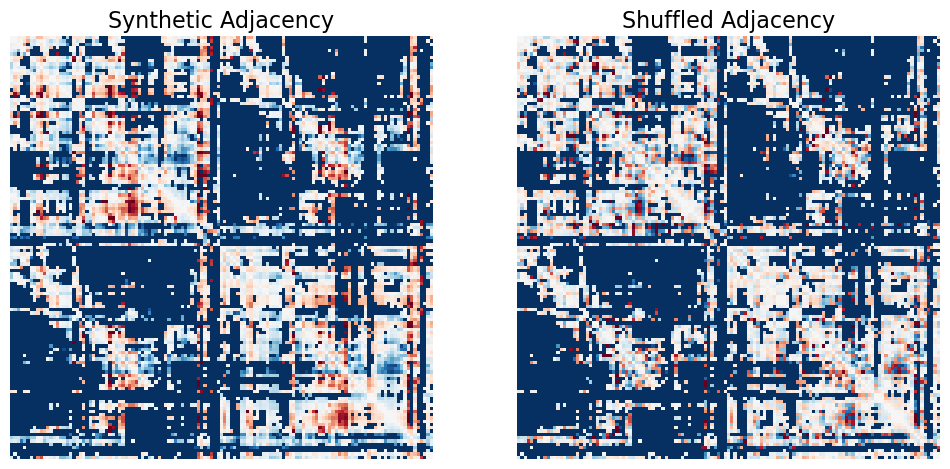

In [15]:
importlib.reload(dgsp)

n_shuffle = 10
shuffled = dgsp.shuffle_edges_sym(graph, perm_prop=0.5, n_shuffle=n_shuffle)

fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
axes[0].set_title("Synthetic Adjacency", fontsize=16)
axes[0].imshow(graph, cmap='RdBu_r', vmin=0, vmax=graph.max(), interpolation="none")
axes[0].axis("off")

axes[1].set_title("Shuffled Adjacency", fontsize=16)
axes[1].imshow(shuffled[0], cmap='RdBu_r', vmin=0, vmax=graph.max(), interpolation="none")
axes[1].axis("off")

In [16]:
importlib.reload(dgsp)

bicom_id = 2

edge_clusters_mat = all_e_mats[bicom_id]
row_ind, col_ind = all_conj[bicom_id]
c2r = {c: r for c, r in zip(col_ind, row_ind)}

print(edge_clusters_mat.max())

n_shuffle = 5000
perm_prop = 0.5

bicoms_masks = np.array([edge_clusters_mat == (i+1) for i in range(edge_clusters_mat.max())])
# true_ratio = dgsp.get_conjugate_ratio(graph, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks)
true_ratio = dgsp.get_asym_ratio(graph, bicom_masks=bicoms_masks)
all_ratios_sym = np.zeros((n_shuffle, len(true_ratio)))

all_shuffled = dgsp.shuffle_edges_sym(graph, perm_prop=perm_prop, n_shuffle=n_shuffle)

for s_i, shuffled in enumerate(all_shuffled):
    # shuffled_ratio = dgsp.get_conjugate_ratio(shuffled, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks)
    shuffled_ratio = dgsp.get_asym_ratio(shuffled, bicom_masks=bicoms_masks)
    all_ratios_sym[s_i] = shuffled_ratio

44


In [17]:
all_ratios_sym = np.nan_to_num(all_ratios_sym, nan=0.5)

In [18]:
bw_adjust = 0.1

# fig, axes = plt.subplots(ncols=2, figsize=(6, 6), gridspec_kw={'width_ratios': [1, 0.2], 'wspace':0})

# cmap = plt.get_cmap("magma", 3)
# axes[0].scatter([true_ratio]*n_shuffle, all_ratios_sym, color=cmap(1), alpha=0.1, edgecolors="none")
# axes[0].scatter(true_ratio, true_ratio, label="True", marker="s", s=50, color="w", edgecolors="k", alpha=0.7, zorder=1)

# axes[0].set_xlabel("True Directionality", fontsize=16)
# axes[0].set_ylabel("Mean Bicomm. Ratio", fontsize=16)

perm_dist = all_ratios_sym.flatten()

# kde = gaussian_kde(perm_dist, bw_method=bw_adjust)
# x = np.linspace(min(true_dir), max(true_dir), 1000)
# y = kde(x)
# y = y / y.max()  # Normalize for better visualization
# axes[1].plot(y, x, lw=4, color=cmap(1))
# axes[1].axis("off")
# axes[1].scatter([0.5]*len(true_dir), true_dir, s=20, marker="s", color="w", edgecolor="k", zorder=3)

all_ps = np.ones_like(true_ratio)
for i, t in enumerate(true_ratio):

    # p_two = (1 + np.sum(np.abs(perm_dist - perm_dist.mean()) >= abs(t - perm_dist.mean()))) / (1 + len(perm_dist))
    biggersum = np.sum(np.abs(all_ratios_sym[:, i] - all_ratios_sym[:, i].mean()) >= abs(t - all_ratios_sym[:, i].mean()))
    p_two = (1 + biggersum) / (1 + n_shuffle)
    # p_one = (1 + np.sum(perm_dist >= t)) / (1 + len(perm_dist))
    all_ps[i] = p_two

sig_df = pd.DataFrame({
    "Bicomm_ID": np.arange(1, len(true_ratio)+1),
    "directionality": true_ratio,
    "abs_dir": np.abs(true_ratio - 0.5),
    "p_value": all_ps,
    "p_corr": all_ps * len(all_ps)
    })

sig_df["is_sig"] = sig_df["p_corr"] < 0.05
sig_df.sort_values(["is_sig", "abs_dir"], ascending=[False, False], inplace=True)
sig_df.head()

,Bicomm_ID,directionality,abs_dir,p_value,p_corr,is_sig
7,8,0.682802,0.182802,0.0002,0.008798,True
29,30,0.647981,0.147981,0.0002,0.008798,True
42,43,0.606168,0.106168,0.0002,0.008798,True
3,4,0.595341,0.095341,0.0002,0.008798,True
18,19,0.409876,0.090124,0.0002,0.008798,True


In [19]:
# sort_by_p = np.argsort(all_ps)
# print(f"{all_ps.min():1.1e}")

# rand_x = np.random.uniform(-0.3, 0.3, n_shuffle)

# cluster_cmap = cmaps["extended_ncar"].resampled(edge_clusters_mat.max())
# fig, axes = plt.subplots(nrows=2, figsize=(10, 6),
#                          gridspec_kw={"height_ratios": [1, 0.5], "hspace": 0},
#                          sharex=True)

# maxval = np.max([all_ratios_sym.max(), true_ratio.max()*1.03])
# # cmap = plt.get_cmap("magma", 3)
# print(len(row_ind))
# cmap = plt.get_cmap("gist_ncar", len(row_ind))
# col_idx = np.arange(len(row_ind))
# for i, sort_i in enumerate(sort_by_p):

#     if sort_i in c2r.keys():
#         colmask = col_idx[row_ind == c2r[sort_i]] + 1
#     else:
#         colmask = col_idx[row_ind == sort_i] + 1

#     if len(sort_by_p) == len(true_ratio):
#         colmask = [7]

#     axes[0].scatter(rand_x + i, all_ratios_sym[:, sort_i], color=cluster_cmap(i), s=20, alpha=0.1, edgecolors="none")
#     # axes[0].scatter(rand_x + i, all_ratios_sym[:, sort_i], color=cmap(1), s=20, alpha=0.1, edgecolors="none")
#     # axes.scatter(i, true_ratio[sort_i], label="True", marker="s", s=50, color="w", edgecolors="k", alpha=0.7, zorder=1)
#     axes[0].bar(i, true_ratio[sort_i]-0.5, bottom=0.5, zorder=1,
#              lw=2, edgecolor="k", color="none")
#     if all_ps[sort_i] < 0.05:
#         axes[0].scatter(i, maxval, marker="$*$", color="k")
#     if all_ps[sort_i] < 0.01:
#         axes[0].scatter(i, maxval*0.99, marker="$*$", color="k")
#     if all_ps[sort_i] < 0.001:
#         axes[0].scatter(i, maxval*0.98, marker="$*$", color="k")

# axes[0].axhline(0.5, lw=2, color="k")
# axes[0].set_ylabel("Mean Bicomm. Ratio", fontsize=16)
# # axes.set_ylim(0.421, 0.579)

# axes[1].plot(all_dist[bicom_id][sort_by_p])
# axes[1].set_xlabel("Bicom. ID", fontsize=16)

Bonferroni corrected p-value threshold: 1.1e-03 (min p: 2.0e-04)
25


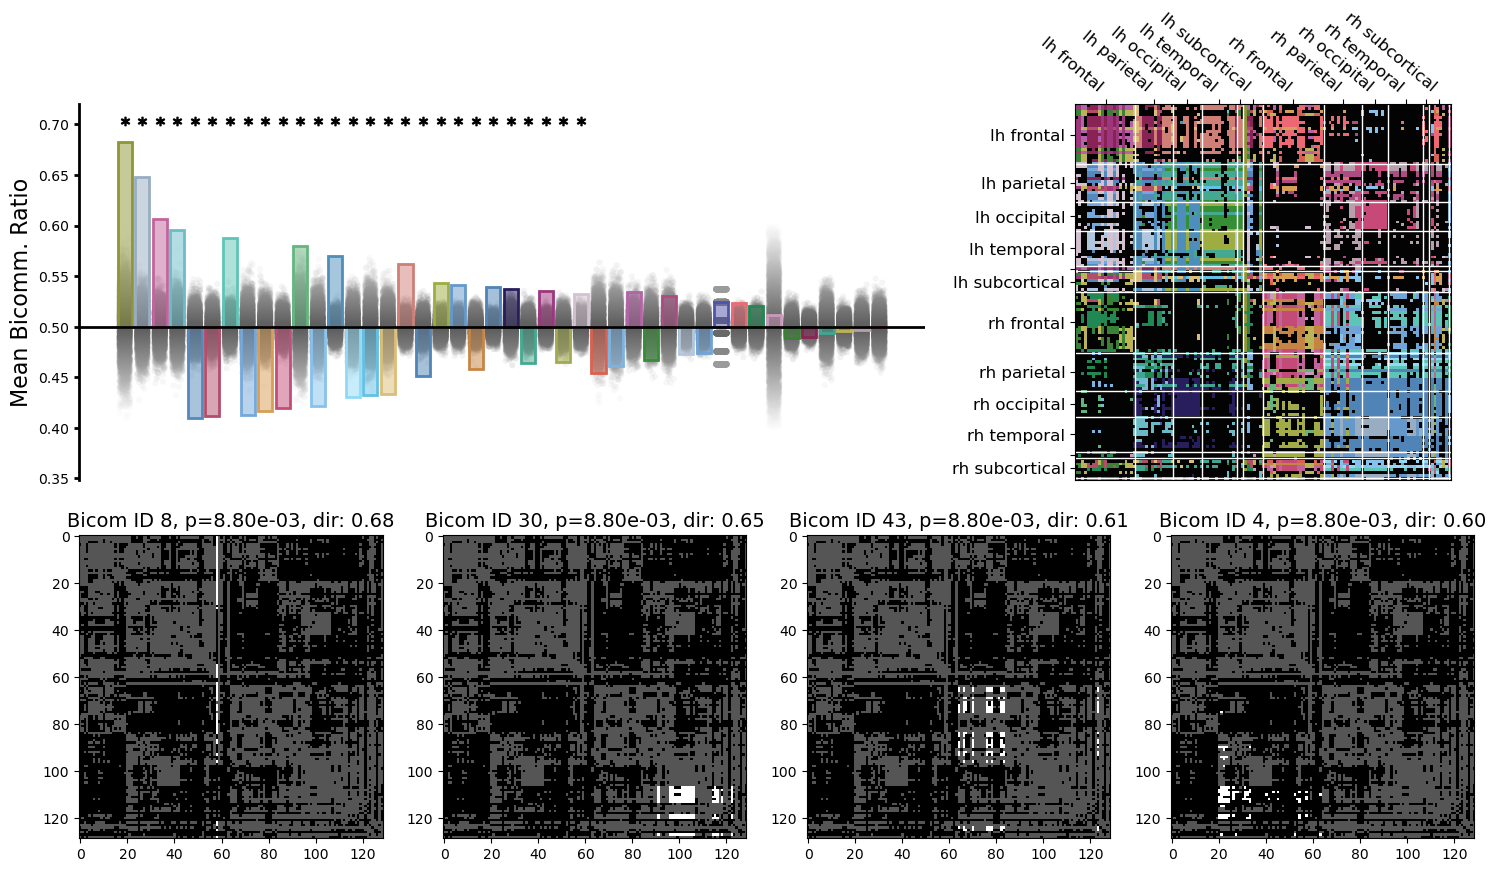

In [20]:
importlib.reload(plot)

# sort_by_p = np.argsort(all_ps)
sort_by_p = sig_df["Bicomm_ID"].values - 1
bonf_thresh = 0.05 / len(true_ratio)
print(f"Bonferroni corrected p-value threshold: {bonf_thresh:1.1e} (min p: {all_ps.min():1.1e})")

rand_x = np.random.uniform(-0.3, 0.3, n_shuffle)

cluster_cmap = cmaps["extended_ncar"].resampled(edge_clusters_mat.max()+1)
fig, all_axes = plt.subplots(nrows=2, figsize=(18, 10), gridspec_kw={"height_ratios": [1, 1], "hspace": 0.05})

all_axes[0].axis("off")
gs = GridSpecFromSubplotSpec(1, 2, subplot_spec=all_axes[0].get_subplotspec(),
                             wspace=0.2, width_ratios=[2, 1])
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

maxval = np.max([all_ratios_sym.max(), true_ratio.max()*1.03])
# cmap = plt.get_cmap("magma", 3)
print(len(row_ind))

for i, sort_i in enumerate(sort_by_p):
    # axes[0].scatter(rand_x + i, all_ratios_sym[:, sort_i], color="k", s=20, alpha=0.05, edgecolors="none")
    axes[0].scatter(rand_x + i, all_ratios_sym[:, sort_i], c=np.abs(0.5 - all_ratios_sym[:, sort_i]), s=20,
                    cmap="binary_r", alpha=0.1, edgecolors="none", vmin=-0.06, vmax=0.1)
    # axes[0].scatter(rand_x + i, all_ratios_sym[:, sort_i], color=cmap(1), s=20, alpha=0.1, edgecolors="none")
    # axes.scatter(i, true_ratio[sort_i], label="True", marker="s", s=50, color="w", edgecolors="k", alpha=0.7, zorder=1)
    # col = cluster_cmap(i)
    col = cluster_cmap(sort_i + 1)
    axes[0].bar(i, true_ratio[sort_i]-0.5, bottom=0.5, zorder=1,
             lw=2, edgecolor="none", color=col, alpha=0.5)
    axes[0].bar(i, true_ratio[sort_i]-0.5, bottom=0.5, zorder=1,
             lw=2, edgecolor=col, color="none")
    
    if sig_df.loc[sig_df["Bicomm_ID"] == (sort_i + 1), "is_sig"].values:
        axes[0].scatter(i, maxval, marker="$*$", color="k")

    # if all_ps[sort_i] < 0.05:
    #     axes[0].scatter(i, maxval, marker="$*$", color="k")
    # if all_ps[sort_i] < 0.01:
    #     axes[0].scatter(i, maxval*0.99, marker="$*$", color="k")
    # if all_ps[sort_i] < 0.001:
    #     axes[0].scatter(i, maxval*0.98, marker="$*$", color="k")

axes[0].axhline(0.5, lw=2, color="k")
axes[0].set_ylabel("Mean Bicomm. Ratio", fontsize=16)
axes[0].spines[["top", "right", "bottom"]].set_visible(False)
axes[0].spines[:].set_linewidth(2)
axes[0].tick_params(which='both', bottom=False, labelbottom=False, width=2)
# axes.set_ylim(0.421, 0.579)

# axes[1].imshow(edge_clusters_mat, cmap=cluster_cmap, interpolation="none")

axes[1].imshow(edge_clusters_mat[order_by_lobe][:, order_by_lobe], cmap=cluster_cmap, vmin=0, vmax=edge_clusters_mat.max(), interpolation="none")
plot.plot_lobe_lines(axes[1], lobe_sizes, lobe_labels, no_insula=True) #, y_only=True)

all_axes[1].axis("off")

gs = GridSpecFromSubplotSpec(1, 4, subplot_spec=all_axes[1].get_subplotspec())
axes_check = [fig.add_subplot(gs[i]) for i in range(4)]

for i, ax in enumerate(axes_check):
    # ax.axis("off")
    ax.set_title(f"Bicom ID {sig_df['Bicomm_ID'].iloc[i]}, p={sig_df['p_corr'].iloc[i]:.2e}, dir: {sig_df['directionality'].iloc[i]:.2f}", fontsize=14)
    bimask = 2*(edge_clusters_mat == sig_df["Bicomm_ID"].iloc[i]).astype(int)
    bimask += (edge_clusters_mat > 0)
    ax.imshow(bimask[order_by_lobe][:, order_by_lobe], cmap="gray", interpolation="none")
    # ax.imshow(edge_clusters_mat[order_by_lobe][:, order_by_lobe] == sig_df["Bicomm_ID"].iloc[i], cmap="gray", interpolation="none")

fig.savefig(op.join(path_to_figures, f"Directionality_K{edge_clusters_mat.max()}{fig_suffix}.png"), dpi=300, bbox_inches='tight')

## Loading Centroids

In [21]:
thal_ids = np.array(np.where(["thalamus" in l for l in labels])[0]) + 1
n_thal_sub = 7

# thal_ids = {2: [58-64, 128-134]}
thal_ids_scale = {
    2: [np.arange(58, 65), np.arange(128, 135)]
    }
thal_ids_bundles = thal_ids_scale[scale]

In [22]:
sel_id = 0
selected_bicom = sort_by_p[sel_id] + 1
print(f"Bicom {selected_bicom} selected (rank {sel_id+1})")

e_array = np.array(np.where(edge_clusters_mat == selected_bicom)) + 1

selected_bundles = []
selected_bundles_dir = []
for e in e_array.T:

    s_r_list = []
    for s_r in e:
        if s_r < thal_ids[0]:
            s_r_list.append([s_r])
        elif s_r == thal_ids[0]:
            s_r_list.append(thal_ids_bundles[0])
        elif s_r < thal_ids[1]:
            s_r_list.append([s_r + n_thal_sub - 1])
        elif s_r == thal_ids[1]:
            s_r_list.append(thal_ids_bundles[1])
        else:
            s_r_list.append([s_r + n_thal_sub*2 - 2])

    # fixed_e = [f"{s}_{r}" for s in s_r_list[0] for r in s_r_list[1]]
    fixed_e = [[s, r] for s in s_r_list[0] for r in s_r_list[1]]
    dir_e = [s > r for s, r in fixed_e]
    
    fixed_e = [f"{s}_{r}" if not d else f"{r}_{s}" for (s, r), d in zip(fixed_e, dir_e)]
    
    selected_bundles.extend(fixed_e)
    selected_bundles_dir.extend(dir_e)

selected_bundles_dir = np.array(selected_bundles_dir)
selected_bundles = np.array(selected_bundles)

Bicom 8 selected (rank 1)


In [23]:
# Location of the atlas
# group_bund_cent = "/media/COSAS/Yasser/Work2Do/Connectome_Atlas/Results/Concatenated/scale2/group_centroids/"
group_bund_cent =  "/Users/acionca/data/atlas_data/centroids/scale2/group_centroids_scale2"

# scale_id = scale_id.replace(" ", "").lower()
print(f"Processing scale: {scale}")

# Centroids HDF5 file
h5_centroids_file = os.path.join(group_bund_cent, f"wm.connatlas.scale{scale}.centroids.h5")

# Reading the HDF5 file
hf = h5py.File(h5_centroids_file, "r")
bundles = list(hf.get("centroids").keys())

# Creating the new h5 file
tempVar = hf.get("header/affine")
affine = np.array(tempVar)
print("Affine:", affine)

# Select only the selected bundles
# bundles = [b for b in bundles if b in selected_bundles]
bundles_dir = [d for b, d in zip(selected_bundles, selected_bundles_dir) if b in bundles]
bundles = [b for b in selected_bundles if b in bundles]

print(f"Plotting {len(bundles)} bundles out of {len(selected_bundles)} selected bundles !")

stl_coord_list = []
stl_bund_id = []
stl_send_list = []
stl_rec_list = []
stl_dir_list = []

n_kept = 2
# n_kept = 1

for bund_id, (bund, direction) in enumerate(zip(bundles, bundles_dir)):
    # Read the group data
    data = hf.get("centroids/" + bund)
    streamlines_matrix = np.array(data)

    sl_coords = []
    sl_send = []
    sl_rec = []
    sl_id = []
    sl_dir = []
    
    # Do a loop along the streamlines
    stl_ids = np.unique(streamlines_matrix[:, 3])
    for stl_id in stl_ids:
        ind = streamlines_matrix[:, 3] == stl_id
        stl_coord = streamlines_matrix[ind, :3]
        stl_send = streamlines_matrix[ind, 4]
        stl_rec = streamlines_matrix[ind, 5]

        # mean_sl = stl_coord.mean(axis=0)
        # # d_mat = cdist(stl_coord, stl_coord)
        # d_mat = np.pow(stl_coord - mean_sl, 2).sum(axis=1)
        # kept_sl = np.argsort(d_mat)[:n_kept]
        
        # Append coordinates
        sl_coords.append(stl_coord)
        
        # For data_per_point, each streamline needs its own array
        # Reshape to (n_points, 1) for TRK format
        sl_id.append(np.ones((len(stl_coord), 1), dtype=np.float32) * bund_id)
        sl_send.append(stl_send.reshape(-1, 1).astype(np.float32))
        sl_rec.append(stl_rec.reshape(-1, 1).astype(np.float32))
        if direction is True:
            sl_dir.append(stl_rec.reshape(-1, 1).astype(np.float32))
        else:
            sl_dir.append(stl_send.reshape(-1, 1).astype(np.float32))

        # # Append coordinates
        # stl_coord_list.append(stl_coord)
        
        # # For data_per_point, each streamline needs its own array
        # # Reshape to (n_points, 1) for TRK format
        # stl_bund_id.append(np.ones((len(stl_coord), 1), dtype=np.float32) * bund_id)
        # stl_send_list.append(stl_send.reshape(-1, 1).astype(np.float32))
        # stl_rec_list.append(stl_rec.reshape(-1, 1).astype(np.float32))
    
    mean_sl = np.median(sl_coords, axis=0)
    # print(mean_sl.shape)

    if n_kept == 1:
        stl_coord_list.extend([mean_sl])
        stl_bund_id.extend([(np.ones(len(mean_sl))*bund_id).reshape(-1, 1)])
        stl_send_list.extend(np.linspace(1, -1, len(mean_sl), endpoint=True).reshape(-1, 1))
        stl_rec_list.extend(np.linspace(-1, 1, len(mean_sl), endpoint=True).reshape(-1, 1))
        #stl_dir_list.extend(np.linspace(-1, 1, len(mean_sl), endpoint=True).reshape(-1, 1))
    else:
        # print(mean_sl.shape)
        d_mat = np.pow(np.array(sl_coords) - mean_sl, 2).sum(axis=(1, 2))
        kept_sl = np.argsort(d_mat)[:n_kept]

        stl_coord_list.extend(np.array(sl_coords)[kept_sl])
        stl_bund_id.extend(np.array(sl_id)[kept_sl])
        stl_send_list.extend(np.array(sl_send)[kept_sl])
        stl_rec_list.extend(np.array(sl_rec)[kept_sl])
        stl_dir_list.extend(np.array(sl_dir)[kept_sl])

print(len(stl_coord_list), stl_coord_list[0].shape)

# Close the HDF5 file
hf.close()

# Create tractogram with the affine matrix
centroid_tractogram = nib.streamlines.Tractogram(
    stl_coord_list,
    affine_to_rasmm=np.eye(4)  # Use the affine from the HDF5 file
)

# Add data per_point to the tractogram
centroid_tractogram.data_per_point['bundle_id'] = stl_bund_id
centroid_tractogram.data_per_point['send'] = stl_send_list
centroid_tractogram.data_per_point['rec'] = stl_rec_list

# centroid_file = os.path.join('/home/yaleman', f'wm.connatlas.{scale_id}.selected_centroids.trk')
centroid_file = os.path.join(group_bund_cent, f"saved_centroids-scale{scale}", f'wm.connatlas.scale{scale}.bicom{selected_bicom}of{edge_clusters_mat.max()}.trk')
os.makedirs(os.path.dirname(centroid_file), exist_ok=True)

# Save with a reference image if available, or just with the tractogram
# nib.streamlines.save(
#     centroid_tractogram,
#     centroid_file,
# )

Processing scale: 2
Affine: [[   1.    0.    0.  -96.]
 [   0.    1.    0. -132.]
 [   0.    0.    1.  -78.]
 [   0.    0.    0.    1.]]
Plotting 76 bundles out of 77 selected bundles !
152 (12, 3)


bundle_id
send
rec


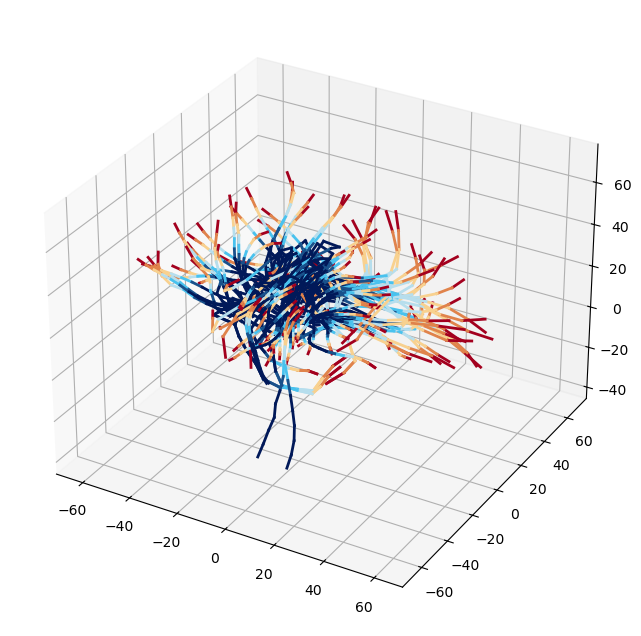

In [24]:
for k in centroid_tractogram.data_per_point.keys():
    print(k)

centroid_tractogram.data_per_point["send"]

sl_cmap = cmaps["div_rb"].resampled(13)
fig, axes = plt.subplots(figsize=(8, 8), subplot_kw={'projection':'3d'})
for sli, sl in enumerate(centroid_tractogram.streamlines):
    
    if n_kept == 1:
        col = centroid_tractogram.data_per_point["send"]
    else:
        col = centroid_tractogram.data_per_point["send"][sli].flatten()
    # axes.scatter(sl[:, 0], sl[:, 1], sl[:, 2], s=10, c=col, cmap=cmaps["div_rb"], alpha=0.2, edgecolors="none")
    for l_i, line in enumerate(sl[:-1]):
        l_coords = sl[l_i:l_i+2]
        axes.plot(l_coords[:, 0], l_coords[:, 1], l_coords[:, 2], color=sl_cmap(col[l_i]), lw=2)
    # plt.plot(sl[:, 0], sl[:, 1], lw=2, c=col, cmap="RdBu_r", alpha=0.1)

In [25]:
from dipy.viz import window, actor
from dipy.viz import window, actor
from dipy.io.streamline import load_tractogram
from dipy.tracking.streamline import transform_streamlines, length

from nilearn.datasets import fetch_surf_fsaverage
from nilearn.surface import load_surf_mesh

fsaverage = fetch_surf_fsaverage()

brain_actors = []
for surf in ["pial_left", "pial_right"]:
    coords, faces = load_surf_mesh(fsaverage[surf])
    surf_act = actor.surface(coords, faces, smooth="loop")
    surf_act.GetProperty().SetOpacity(0.3)
    brain_actors.append(surf_act)

# Load streamlines (.trk, .tck, .fib, etc.)
# tractogram = load_tractogram(centroid_file, "same", bbox_valid_check=False)
# streamlines = transform_streamlines(tractogram.streamlines, np.linalg.inv(tractogram.affine))
tractogram = centroid_tractogram
# streamlines = transform_streamlines(tractogram.streamlines, np.eye(4))
streamlines = tractogram.streamlines

hue = (0.7, 1)  # blue only
saturation = (1.0, 1.0)  # black to white

lut_cmap = actor.colormap_lookup_table(
    scale_range=(-1, 1),
    hue_range=hue,
    saturation_range=saturation,
)

rng = np.random.default_rng()

colors_r = [rng.random(sl.shape) for sl in streamlines]

sline_cmap = cmaps["div_rb"].resampled(13)
colors = np.array([sline_cmap((6*(1 + sl)).astype(int)) for sl in centroid_tractogram.data_per_point["send"]])
print(colors.shape)
if n_kept == 1:
    colors = colors[:, 0, :3]
else:
    colors = colors[:, :, 0, :3]

# Add actors to the scene
stream_actor = actor.line(streamlines, colors=np.asarray(colors, dtype=object), linewidth=2)
# stream_actor = actor.line(streamlines, colors=centroid_tractogram.data_per_point["send"], linewidth=2, lookup_colormap=lut_cmap)
# stream_actor2 = actor.line(bundle_native, colors=fa, linewidth=0.1)
bar = actor.scalar_bar(lookup_table=lut_cmap)

tube_actor = actor.streamtube(streamlines, colors=np.asarray(colors, dtype=object), linewidth=0.5)

(152, 12, 1, 4)


/Users/acionca/fsl/envs/dgsp/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: UserWarning: We'll no longer accept the way you call the surface function in future versions of FURY.

Here's how to call the Function surface: surface(vertices_value, faces='value', colors='value', smooth='value', subdivision='value')

  exec(code_obj, self.user_global_ns, self.user_ns)


In [33]:
scene = window.Scene()

# scene.add(stream_actor)
scene.add(tube_actor)
# scene.add(bar)

for act in brain_actors:
    scene.add(act)

window.show(scene, occlusion_ratio=0.4)


In [191]:
# from nilearn.datasets import fetch_surf_fsaverage
# from nilearn.surface import load_surf_mesh

# overlay_slines = False

# fsaverage = fetch_surf_fsaverage()

# fig, axes = plt.subplots(figsize=(8, 8))
# scene = window.Scene()

# # White background
# scene.SetBackground((1, 1, 1))

# brain_actors = []
# for surf in ["pial_left", "pial_right"]:
#     coords, faces = load_surf_mesh(fsaverage[surf])
#     surf_act = actor.surface(coords, faces, smooth="loop")
#     if not overlay_slines:
#         surf_act.GetProperty().SetOpacity(0.3)
#     brain_actors.append(surf_act)
#     scene.add(surf_act)

# if not overlay_slines:
#     # scene.add(stream_actor)
#     scene.add(tube_actor)

# scene.set_camera(position=(0, 0, 350),
#                  focal_point=(0, -15, 0),
#                  view_up=(0.0, 0.0, 0.0))

# win = window.snapshot(scene, size=(2000, 2000), offscreen=True)
# win = np.ascontiguousarray(win)

# axes.imshow(win)

# if overlay_slines:
#     scene2 = window.Scene()
#     scene2.SetBackground((0, 1, 0))
#     scene2.add(tube_actor)

#     win = window.snapshot(scene2, size=(2000, 2000), offscreen=True)
#     win = np.ascontiguousarray(win)

#     win_mask = ((win == (0, 255, 0)).sum(axis=-1) < 3).astype(float)
#     win = np.concatenate([win, 255*win_mask[:, :, None]], axis=-1).astype(int)

#     axes.imshow(win)

/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_65457/2233362938.py:3: UserWarning: We'll no longer accept the way you call the surface function in future versions of FURY.

Here's how to call the Function surface: surface(vertices_value, faces='value', colors='value', smooth='value', subdivision='value')

  brain_actors = plot.get_brain_actors(opacity=0.2)


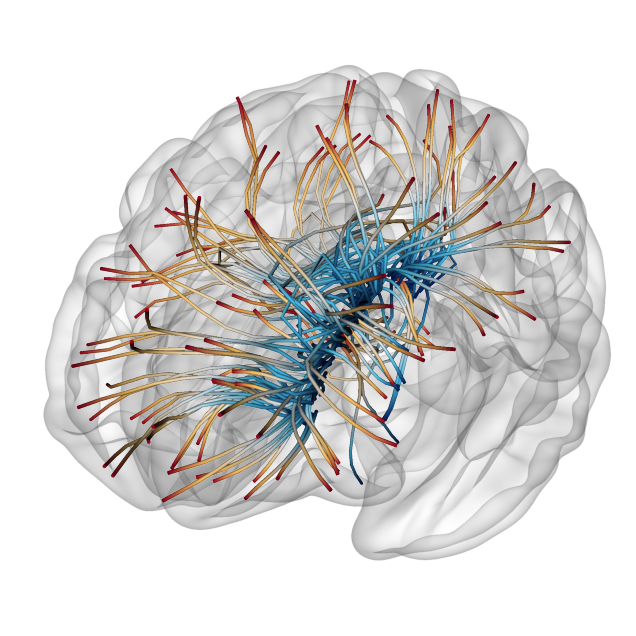

In [226]:
importlib.reload(plot)

brain_actors = plot.get_brain_actors(opacity=0.2)
tube_actor = plot.get_tube_actor(centroid_tractogram, cmaps["div_rb"], n_kept=n_kept, n_colors=13, linewidth=0.5)

fig, axes = plt.subplots(figsize=(8, 8))

axes.axis("off")
plot.plot_bundle_surf(tube_actor, brain_actors, view="custom", axes=axes,
                      overlay_slines=True)

/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_65457/2112967310.py:3: UserWarning: We'll no longer accept the way you call the surface function in future versions of FURY.

Here's how to call the Function surface: surface(vertices_value, faces='value', colors='value', smooth='value', subdivision='value')

  brain_actors = plot.get_brain_actors(opacity=0.2)


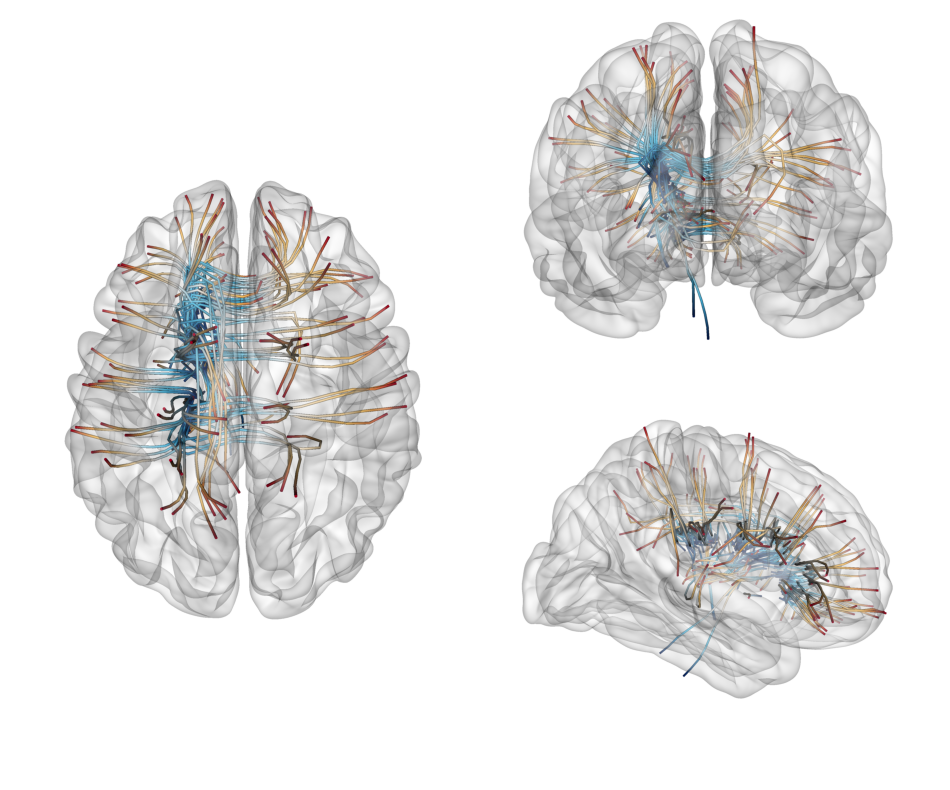

In [190]:
importlib.reload(plot)

brain_actors = plot.get_brain_actors(opacity=0.2)
tube_actor = plot.get_tube_actor(centroid_tractogram, cmaps["div_rb"], n_kept=n_kept, n_colors=13, linewidth=0.5)

fig, axes = plt.subplots(
    ncols=2, figsize=(12, 10),
    gridspec_kw={'wspace':0, "width_ratios":[1, 1]}
    )

axes[1].axis("off")
gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=axes[1].get_subplotspec(), hspace=0)

b_axes = [axes[0]] + [fig.add_subplot(gs[i]) for i in range(2)]

for ax, view in zip(b_axes, ["transverse", "coronal", "sagittal"]):
    plot.plot_bundle_surf(tube_actor, brain_actors, view=view, axes=ax)
    ax.axis("off")

## Loading F-Tract

In [ ]:
importlib.reload(dload)

path_to_ftract = "/Users/acionca/data/F-TRACT-Lausanne2008"
maxdelay = 50

prob, delay, ftract_labels = dload.get_ftract_data(path_to_ftract, scale=2, maxdelay=maxdelay)

print(f"F-Tract probability has shape {prob.shape} (EC has shape {graph.shape})")
invdelay = np.divide(1, delay, out=np.zeros_like(delay), where=delay > 1e-5)

# fig, axes = plt.subplots(ncols=3, figsize=(18, 6))

# axes[0].imshow(graph, cmap='RdBu_r', vmin=0, vmax=1, interpolation="none")
# axes[1].imshow(delay, cmap='RdBu_r', vmin=0, vmax=delay.max(), interpolation="none")
# axes[2].imshow(invdelay, cmap='RdBu_r', vmin=0, vmax=invdelay.max()*0.1, interpolation="none")

In [ ]:
importlib.reload(dgsp)

nzer_mask = np.logical_and(delay > 1e-5, k_matrix > 0)

fig, axes = plt.subplots(figsize=(12, 6))

graph_ratio = np.divide(graph, graph + graph.T, out=np.zeros_like(graph, dtype=float), where=(graph + graph.T) > 0)
f_ratio = np.divide(delay.T, delay + delay.T, out=np.zeros_like(graph_ratio), where=(delay + delay.T) > 0)
corr_edge = np.corrcoef(graph_ratio[nzer_mask], f_ratio[nzer_mask])[0, 1]

# ftract_ratio = dgsp.get_conjugate_ratio(invdelay, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks)
# ec_ratio = dgsp.get_conjugate_ratio(graph, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks)
ftract_ratio = dgsp.get_asym_ratio(invdelay, bicom_masks=bicoms_masks)
ec_ratio = dgsp.get_asym_ratio(graph, bicom_masks=bicoms_masks)
corr_bicom = np.corrcoef(ftract_ratio, ec_ratio)[0, 1]

edge_clusters = edge_clusters_mat[edge_clusters_mat > 0]
edge_clusters_perm = np.random.permutation(edge_clusters)
edge_clusters_mat_perm = np.zeros_like(edge_clusters_mat)
edge_clusters_mat_perm[edge_clusters_mat > 0] = edge_clusters_perm
bicoms_masks_perm = np.array([edge_clusters_mat_perm == (i+1) for i in range(edge_clusters_mat.max())])

# ft_perm_ratio = dgsp.get_conjugate_ratio(invdelay, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks_perm)
# ec_perm_ratio = dgsp.get_conjugate_ratio(graph, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks_perm)
ft_perm_ratio = dgsp.get_asym_ratio(invdelay, bicom_masks=bicoms_masks_perm)
ec_perm_ratio = dgsp.get_asym_ratio(graph, bicom_masks=bicoms_masks_perm)
corr_rand = np.corrcoef(ft_perm_ratio, ec_perm_ratio)[0, 1]

axes.scatter(graph_ratio[nzer_mask], f_ratio[nzer_mask], alpha=0.4, s=20, edgecolor="none", label=f"Edge $\\rho={corr_edge:.2f}$")
axes.scatter(ftract_ratio, ec_ratio, alpha=1, s=100, edgecolor="none", label=f"Bicommunity $\\rho={corr_bicom:.2f}$")

# axes.scatter(ft_perm_ratio, ec_perm_ratio, s=50, color="tab:red", edgecolors="none", zorder=1, alpha=0.5,
#              label=f"Permuted Bicommunity $\\rho={corr_rand:.2f}$")

axes.legend(fontsize=16)

In [ ]:
from sklearn.linear_model import LinearRegression

def get_loo_curves(f_ratio, e_ratio, x_plot=None):
    if x_plot is None:
        x_plot = np.linspace(0, 1, 100)

    all_yvals = []
    all_corrs = []
    for k, _ in enumerate(f_ratio):
        loo_mask = ~np.eye(len(f_ratio), dtype=bool)[k]
        ftract_loo = f_ratio[loo_mask]
        ec_loo = e_ratio[loo_mask]
        
        all_corrs.append(np.corrcoef(ec_loo, ftract_loo)[0, 1])

        reg = LinearRegression().fit(ec_loo.reshape(-1, 1), ftract_loo.reshape(-1, 1))
        reg.score(ec_loo.reshape(-1, 1), ftract_loo.reshape(-1, 1))

        y_vals = reg.intercept_[0] + reg.coef_[0]*x_plot
        all_yvals.append(y_vals)

    return np.array(all_yvals), np.array(all_corrs)

loo_yvals, loo_corrs = get_loo_curves(ftract_ratio, ec_ratio)

In [ ]:
nzer_mask = np.logical_and(delay > 1e-5, k_matrix > 0)

fig, axes = plt.subplots(figsize=(12, 8))

graph_ratio = np.divide(graph, graph + graph.T, out=np.zeros_like(graph, dtype=float), where=(graph + graph.T) > 0)
f_ratio = np.divide(delay.T, delay + delay.T, out=np.zeros_like(graph_ratio), where=(delay + delay.T) > 0)
corr_edge = np.corrcoef(graph_ratio[nzer_mask], f_ratio[nzer_mask])[0, 1]

axes.scatter(graph_ratio[nzer_mask], f_ratio[nzer_mask], alpha=0.4, s=20, edgecolor="none", label=f"Edge $\\rho={corr_edge:.2f}$")

x_plot = np.linspace(0, 1, 100)
all_yvals, all_corrs = get_loo_curves(ftract_ratio, ec_ratio, x_plot=x_plot)

all_rand_yvals = []
all_rand_corrs = []
n_selected_edges = len(ftract_ratio)
for t in range(50):
    rand_edges = np.random.choice(np.sum(nzer_mask), size=n_selected_edges, replace=False)
    g_vals = graph_ratio[nzer_mask].flatten()[rand_edges]
    f_vals = f_ratio[nzer_mask].flatten()[rand_edges]

    corr_rand_edges = np.corrcoef(g_vals, f_vals)[0, 1]
    all_rand_corrs.append(corr_rand_edges)

    reg = LinearRegression().fit(g_vals.reshape(-1, 1), f_vals.reshape(-1, 1))
    reg.score(g_vals.reshape(-1, 1), f_vals.reshape(-1, 1))

    y_vals = reg.intercept_[0] + reg.coef_[0]*x_plot
    all_rand_yvals.append(y_vals)
    

axes.plot(x_plot, np.mean(all_rand_yvals, axis=0), lw=2, color="tab:blue", ls="--")
axes.fill_between(x_plot, np.max(all_rand_yvals, axis=0), np.min(all_rand_yvals, axis=0),
                  color="tab:blue", alpha=0.3, zorder=0, edgecolor="none")

axes.scatter(ec_ratio, ftract_ratio, alpha=1, s=100, edgecolor="k",
             label=f"Bicommunity $\\rho={corr_bicom:.2f}$ (min: ${np.min(all_corrs):.2f}$, max: ${np.max(all_corrs):.2f}$)", zorder=3)
reg = LinearRegression().fit(ec_ratio.reshape(-1, 1), ftract_ratio.reshape(-1, 1))
reg.score(ec_ratio.reshape(-1, 1), ftract_ratio.reshape(-1, 1))

axes.plot(x_plot, reg.intercept_[0] + reg.coef_[0]*x_plot, lw=2, color="k")
axes.fill_between(x_plot, np.max(all_yvals, axis=0), np.min(all_yvals, axis=0),
                  color="tab:orange", alpha=0.6)

axes.set_xlabel("Connectome Asymmetry", fontsize=16)
# axes.set_ylabel("Effective Connectivity Asymmetry", fontsize=16)
axes.set_ylabel("F-TRACT Asymmetry", fontsize=16)
axes.tick_params(labelsize=14, width=2)

axes.spines[["top", "right"]].set_visible(False)
axes.spines[:].set_linewidth(2)

axes.set_ylim(-0.01, 1.01)

axes.legend(fontsize=16)

### Optimal $K$ for Correlation

In [ ]:
# importlib.reload(dgsp)

# k_for_corr = n_clusters[10:90]
# use_bicom = False

# all_corr_bi = np.zeros(len(k_for_corr))
# n_perm = 10
# all_corr_rand = np.zeros((len(k_for_corr), n_perm))

# for i, k in enumerate(k_for_corr):
#     labs = fcluster(Z, t=k+1, criterion='maxclust')

#     e_mat = np.zeros_like(graph, dtype=int)
#     e_mat[graph != 0] = labs

#     bi_masks = np.array([e_mat == (i+1) for i in range(e_mat.max())])

#     if use_bicom:
#         send, rec = dgsp.get_node_clusters(labs, e_mat)
#         row_ind, col_ind = dgsp.get_conjugates_matching(send, rec)

#         ftract_ratio = dgsp.get_conjugate_ratio(invdelay, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks)
#         ec_ratio = dgsp.get_conjugate_ratio(graph, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks)
#     else:
#         ftract_ratio = dgsp.get_asym_ratio(invdelay, bicom_masks=bi_masks)
#         ec_ratio = dgsp.get_asym_ratio(graph, bicom_masks=bi_masks)

#     all_corr_bi[i] = np.corrcoef(ftract_ratio, ec_ratio)[0, 1]

#     edge_clusters = e_mat[e_mat > 0]
#     for j in range(n_perm):
#         edge_clusters_perm = np.random.permutation(edge_clusters)
#         edge_clusters_mat_perm = np.zeros_like(e_mat)
#         edge_clusters_mat_perm[e_mat > 0] = edge_clusters_perm
#         bi_masks_perm = np.array([edge_clusters_mat_perm == (i+1) for i in range(e_mat.max())])

#         if use_bicom:
#             ft_perm_ratio = dgsp.get_conjugate_ratio(invdelay, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks_perm)
#             ec_perm_ratio = dgsp.get_conjugate_ratio(graph, row_ind=row_ind, col_ind=col_ind, bicom_masks=bicoms_masks_perm)
#         else:
#             ft_perm_ratio = dgsp.get_asym_ratio(invdelay, bicom_masks=bi_masks_perm)
#             ec_perm_ratio = dgsp.get_asym_ratio(graph, bicom_masks=bi_masks_perm)
#         all_corr_rand[i, j] = np.corrcoef(ft_perm_ratio, ec_perm_ratio)[0, 1]

# # plt.plot(k_for_corr, all_corr_bi, marker='o', label="Bicommunity")
# # plt.plot(k_for_corr, all_corr_rand.mean(axis=1), marker='o', label="Permuted Bicommunity")
# # plt.fill_between(k_for_corr,
# #                  all_corr_rand.min(axis=1),
# #                  all_corr_rand.max(axis=1),
# #                  color="tab:orange", alpha=0.3, edgecolor="none")

# # plt.xlabel("Number of Clusters (K)", fontsize=16)
# # plt.ylabel("Correlation Coefficient", fontsize=16)
# # plt.title("Correlation between Bicommunity Asymmetry and F-TRACT Asymmetry", fontsize=18)
# # plt.legend(fontsize=14)

In [ ]:
importlib.reload(dgsp)

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
myk = 0

k_for_corr = n_clusters[1:100]
k_for_corr = n_clusters[1:70]
all_delays = [50, 100, 200, 400]
n_perm = 20

all_corr_bi = np.zeros((len(all_delays), len(k_for_corr)))
all_corr_rand = np.zeros((len(all_delays), len(k_for_corr), n_perm))

best_bi = [0]*len(all_delays)
best_rand = [0]*len(all_delays)

edge_scatter = [0]*len(all_delays)
edge_scatter_rand = [0]*len(all_delays)

for d_i, maxdelay in enumerate(all_delays):
    prob, delay, ftract_labels = dload.get_ftract_data(path_to_ftract, scale=2, maxdelay=maxdelay)
    invdelay = np.divide(1, delay, out=np.zeros_like(delay), where=delay > 1e-10)
    print(f"F-Tract probability has shape {prob.shape} (EC has shape {graph.shape})")

    g_ratio = graph.copy()
    # g_ratio[invdelay == 0] = np.nan
    invdelay[invdelay == 0] = np.nan

    nzer_mask = np.logical_and(delay > 1e-5, graph > 0)
    graph_ratio = np.divide(graph, graph + graph.T, out=np.zeros_like(graph, dtype=float), where=(graph + graph.T) > 0)
    f_ratio = np.divide(delay.T, delay + delay.T, out=np.zeros_like(graph_ratio), where=(delay + delay.T) > 0)
    
    edge_scatter[d_i] = (graph_ratio[nzer_mask], f_ratio[nzer_mask])

    maxcorr = -1

    for i, k in enumerate(k_for_corr):
        labs = fcluster(Z, t=k, criterion='maxclust')

        e_mat = np.zeros_like(graph, dtype=int)
        e_mat[graph != 0] = labs

        bi_masks = np.array([e_mat == (i+1) for i in range(e_mat.max())])

        ftract_ratio = dgsp.get_asym_ratio(invdelay, bicom_masks=bi_masks)
        ec_ratio = dgsp.get_asym_ratio(g_ratio, bicom_masks=bi_masks)

        # Handling NaNs
        nanratio = np.logical_or(np.isnan(ftract_ratio), np.isnan(ec_ratio))
        ftract_ratio = ftract_ratio[~nanratio]
        ec_ratio = ec_ratio[~nanratio]

        if sum(nanratio) == len(nanratio):
            print("All NaN in bicom, skipping...")
            continue

        corr = np.corrcoef(ftract_ratio, ec_ratio)[0, 1]
        all_corr_bi[d_i, i] = corr
        if corr > maxcorr:
            maxcorr = corr
            best_bi[d_i] = (ec_ratio, ftract_ratio)
        
        maxrand = -1
        e_rand = []
        for j in range(n_perm):
            edge_clusters_perm = np.random.permutation(labs)
            edge_clusters_mat_perm = np.zeros_like(e_mat)
            edge_clusters_mat_perm[e_mat != 0] = edge_clusters_perm
            bi_masks_perm = np.array([edge_clusters_mat_perm == (i+1) for i in range(edge_clusters_mat_perm.max())])

            ft_perm_ratio = dgsp.get_asym_ratio(invdelay, bicom_masks=bi_masks_perm)
            ec_perm_ratio = dgsp.get_asym_ratio(g_ratio, bicom_masks=bi_masks_perm)

            # Handling NaNs
            nanratio = np.logical_or(np.isnan(ft_perm_ratio), np.isnan(ec_perm_ratio))
            ft_perm_ratio = ft_perm_ratio[~nanratio]
            ec_perm_ratio = ec_perm_ratio[~nanratio]

            if sum(nanratio) == len(nanratio):
                print("All NaN in permutation, skipping...")
                continue

            corr2 = np.corrcoef(ft_perm_ratio, ec_perm_ratio)[0, 1]
            all_corr_rand[d_i, i, j] = corr2
            if (corr == maxcorr) and (corr2 > maxrand):
                maxrand = corr2
                best_rand[d_i] = (ec_perm_ratio, ft_perm_ratio)
                best_perm = edge_clusters_mat_perm

        if k == 20 and myk < len(axes[0]):
            print(best_perm.max())
            corr_rand = np.corrcoef(best_rand[d_i][0], best_rand[d_i][1])[0, 1]
            axes[0, myk].imshow(best_perm, cmap=cmaps["extended_ncar"], vmin=0, vmax=best_perm.max(), interpolation="none")
            axes[0, myk].set_title(f"K={k}, Delay={maxdelay}ms", fontsize=14)
            
            axes[1, myk].scatter(best_rand[d_i][0], best_rand[d_i][1], alpha=1, s=50, color="silver", edgecolor="k")
            axes[1, myk].scatter(best_bi[d_i][0], best_bi[d_i][1], alpha=1, s=100, edgecolor="k")
            axes[1, myk].set_title(f"$\\rho={maxcorr:.2f}$, ($\\rho_{{rand}}={corr_rand:.2f}$)", fontsize=14)
            myk += 1

        #     edge_select =  np.random.choice(np.sum(nzer_mask), size=k, replace=False)
        #     e_rand.append((graph_ratio[nzer_mask][edge_select], f_ratio[nzer_mask][edge_select]))
        
        # edge_scatter_rand[d_i] = e_rand

In [ ]:
from matplotlib.patheffects import withStroke


fig, axes = plt.subplots(nrows=2, figsize=(20, 12))

cmap_plot = cmaps["cluster_palette_soft"]
col_4plots = cmap_plot.resampled(len(all_delays) + 1)

x_plot = np.linspace(0, 1, 100)
perc_plot = 5
plot_loo = False

axes[0].axis("off")
gs = GridSpecFromSubplotSpec(1, len(all_delays), subplot_spec=axes[0].get_subplotspec(), wspace=0.2)
ax_bests = [fig.add_subplot(gs[i]) for i in range(len(all_delays))]

best_per_d = np.zeros(len(all_delays))
old_best_per_d = 0
for d_i, maxdelay in enumerate(all_delays):
    corr_bi = all_corr_bi[d_i]
    color = col_4plots(d_i + 1)
    axes[1].plot(k_for_corr, corr_bi, marker='o', label=f"$d_{{{maxdelay}}}$", color=color)

    rand_del = all_corr_rand[d_i]
    rand_del = np.nan_to_num(rand_del)
    
    # axes[1].scatter([k_for_corr]*n_perm, all_corr_rand[d_i], s=80, alpha=0.1, color="tab:blue", edgecolor="none", zorder=0)
    axes[1].plot(k_for_corr, np.percentile(rand_del, 100 - perc_plot, axis=1), lw=1, color=color, zorder=0)
    axes[1].plot(k_for_corr, np.percentile(rand_del, perc_plot, axis=1), lw=1, color=color, zorder=0)
    axes[1].fill_between(k_for_corr, np.percentile(rand_del, 100 - perc_plot, axis=1), np.percentile(rand_del, perc_plot, axis=1),
                         lw=0, alpha=0.2, color=color, zorder=0)

    corr_bi = np.nan_to_num(corr_bi)
    best_per_d = np.argmax(corr_bi)
    print(k_for_corr[best_per_d], corr_bi.max())

    ha = "left"
    if d_i == 0:
        ha = "right"

    height = 1 - 0.1*d_i
    if best_per_d == old_best_per_d:
        height = 0.86

    old_best_per_d = best_per_d

    # axes[1].plot([k_for_corr[best_per_d]]*2, [corr_bi.max(), 1], lw=4, color=color, alpha=0.5)
    axes[1].plot([k_for_corr[best_per_d]]*2, [0, 1], lw=4, color=color, alpha=0.5)
    axes[1].text(k_for_corr[best_per_d] + 0.2, height, f"$K={k_for_corr[best_per_d]},\\,\\rho={corr_bi.max():.2f}$",
                 fontsize=14, ha="left", va='top', color=color,
                 path_effects=[withStroke(linewidth=2, foreground="w", alpha=0.5)],)

    if plot_loo:
        all_yvals, all_corrs = get_loo_curves(best_bi[d_i][1], best_bi[d_i][0], x_plot=x_plot)
        ax_bests[d_i].plot(x_plot, all_yvals.T, color=color, lw=4, zorder=3, alpha=0.5)
        ax_bests[d_i].plot(x_plot, all_yvals.mean(axis=0), color="k", lw=2, zorder=3)
    else:
        all_corrs = None

    # bi_spear = spearmanr(best_bi[d_i][0], best_bi[d_i][1]).correlation
    ax_bests[d_i].scatter(best_bi[d_i][0], best_bi[d_i][1], s=100, color=color, edgecolor="k",
                        #   label=f"$K={k_for_corr[best_per_d]},$\n$\\rho={corr_bi.max():.2f}$ $({all_corrs.min():.2f},{all_corrs.max():.2f}),$\n$\\rho_{{s}}={bi_spear:.2f}$", zorder=4)
                          label=f"$\\rho={corr_bi.max():.2f}$" + (f" $({all_corrs.min():.2f},{all_corrs.max():.2f})$" if all_corrs is not None else ""), zorder=4)
                        #   label=f"$K={k_for_corr[best_per_d]},\,\\rho={corr_bi.max():.2f}$ $({all_corrs.min():.2f},{all_corrs.max():.2f})$", zorder=4)
    
    corr_rand = np.corrcoef(best_rand[d_i][0], best_rand[d_i][1])[0, 1]
    ax_bests[d_i].scatter(best_rand[d_i][0], best_rand[d_i][1], s=80, color="tab:blue", edgecolor="none", alpha=0.5,
                          label=f"$\\rho={corr_rand.max():.2f}$", zorder=1)
    e_corr = np.corrcoef(edge_scatter[d_i][0], edge_scatter[d_i][1])[0, 1]
    # e_spear = spearmanr(edge_scatter[d_i][0], edge_scatter[d_i][1]).correlation
    ax_bests[d_i].scatter(edge_scatter[d_i][0], edge_scatter[d_i][1], s=20, color="gray", edgecolor="none", alpha=0.2, zorder=0,
                          label=f"$\\rho={e_corr:.2f}$")
    
    ax_bests[d_i].set_xlim(0.3, 0.7)
    ax_bests[d_i].set_ylim(0.01, 0.99)

    ax_bests[d_i].set_ylabel(f"F-TRACT Asymmetry ($d_{{max}}={maxdelay}$ms)", fontsize=14)
    ax_bests[d_i].set_xlabel(f"Connectome Asymmetry", fontsize=14)
    ax_bests[d_i].spines[["top", "right"]].set_visible(False)
    ax_bests[d_i].spines[:].set_linewidth(2)
    ax_bests[d_i].tick_params(labelsize=12, width=2)
    ax_bests[d_i].legend(fontsize=14, loc='upper left')
    ax_bests[d_i].set_title(f"$K={k_for_corr[best_per_d]}$ Bicommunities", fontsize=16)

axes[1].axhline(0, color="k", lw=2, zorder=0)
axes[1].spines[["top", "right", "bottom"]].set_visible(False)
axes[1].spines[:].set_linewidth(2)
axes[1].tick_params(labelsize=12, width=2)

axes[1].set_xlabel("Number of Clusters (K)", fontsize=16)
axes[1].set_ylabel("Correlation Coefficient", fontsize=16)
axes[1].legend(fontsize=14, ncols=len(all_delays))

fig.savefig(op.join(path_to_figures, f"ftract_corr_{n_perm}perm{fig_suffix}.png"), dpi=300, bbox_inches='tight')
fig.savefig(op.join(path_to_figures, f"ftract_corr_{n_perm}perm{fig_suffix}.pdf"), dpi=300, bbox_inches='tight', format="pdf")

In [ ]:
# Adding Gamma

fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)

# k_for_corr = n_clusters[1:100]
# k_for_corr = n_clusters[1:60]
all_delays = [50, 100, 200, 400]
n_perm = 5

all_gammas = np.arange(0.1, 4, 0.2)
# all_gammas = np.logspace(-0.5, 1.5, 10)
# all_gammas = np.array([0.1, 0.5, 1, 2, 4, 8, 10])
all_gammas = np.sort(np.concatenate([all_gammas, np.array([1.0])]))
print(all_gammas)

all_corr_bi = np.zeros((len(all_delays), len(all_gammas), len(k_for_corr)))
all_corr_rand = np.zeros((len(all_delays), len(all_gammas), len(k_for_corr), n_perm))

best_bi = [0]*len(all_delays)
best_rand = [0]*len(all_delays)

mygi = [1, 3, 7]
myki = 33
myki = 18

print(f"k = {k_for_corr[myki]}")
print(f"g = {all_gammas[mygi]}")

for g_i, gamma in enumerate(all_gammas):
    for d_i, maxdelay in enumerate(all_delays):
        prob, delay, ftract_labels = dload.get_ftract_data(path_to_ftract, scale=2, maxdelay=maxdelay)
        invdelay = np.divide(1, delay, out=np.zeros_like(delay), where=delay > 1e-10)

        g_ratio = graph.copy() ** gamma
        # g_ratio[invdelay == 0] = np.nan
        invdelay[invdelay == 0] = np.nan

        maxcorr = 0

        for i, k in enumerate(k_for_corr):
            labs = fcluster(Z, t=k+1, criterion='maxclust')

            e_mat = np.zeros_like(graph, dtype=int)
            e_mat[graph != 0] = labs

            bi_masks = np.array([e_mat == (i+1) for i in range(e_mat.max())])

            ftract_ratio = dgsp.get_asym_ratio(invdelay, bicom_masks=bi_masks)
            ec_ratio = dgsp.get_asym_ratio(g_ratio, bicom_masks=bi_masks)

            nanratio = np.logical_or(np.isnan(ftract_ratio), np.isnan(ec_ratio))

            ftract_ratio = ftract_ratio[~nanratio]
            ec_ratio = ec_ratio[~nanratio]

            corr = np.corrcoef(ftract_ratio, ec_ratio)[0, 1]
            all_corr_bi[d_i, g_i, i] = corr
            # if corr > maxcorr:
            #     maxcorr = corr
            #     best_bi[d_i] = (ec_ratio, ftract_ratio)

            if (g_i in mygi) and (i == myki):
                axes[d_i].scatter(ec_ratio, ftract_ratio, s=100, edgecolor="k", label=f"$\\gamma={gamma:.2f}$ $(\\rho={corr:1.2f})$")

for ax in axes:
    ax.legend(fontsize=12)
    ax.set_xlim(0.35, 0.65)

In [ ]:
fig, axes = plt.subplots(ncols=4, figsize=(20, 5), sharey=True)

xticks = np.linspace(0, len(all_gammas)-1, 5, dtype=int)
for d_i, maxdelay in enumerate(all_delays):
    axes[d_i].set_title(f"Max Delay = {maxdelay} ms", fontsize=16)
    axes[d_i].imshow(all_corr_bi[d_i].T, cmap="magma", aspect="auto", vmax=0.7)

    # axes[d_i].set_xticks(xticks, labels=[f"{all_gammas[i]:.2f}" for i in xticks])
    axes[d_i].set_xticks(np.arange(len(all_gammas)), labels=[f"{g:.2f}" for g in all_gammas])
    axes[d_i].set_xlabel("$\\gamma$")

axes[0].set_ylabel("$K$ Clusters")

In [ ]:
fig, axes = plt.subplots(ncols=4, figsize=(30, 5), sharey=True, gridspec_kw={"wspace":0})

col_per_gamma = cmap_plot.resampled(len(all_gammas) + 1)

for d_i, maxdelay in enumerate(all_delays):
    axes[d_i].set_title(f"Max Delay = {maxdelay} ms", fontsize=16)
    
    for g_i, gamma in enumerate(all_gammas):
        lw = 2
        color = col_per_gamma(g_i + 1)
        if gamma == 1.0:
            lw = 4
            color="k"
        axes[d_i].plot(all_corr_bi[d_i, g_i], alpha=0.5, lw=lw, color=color, label=f"$\\gamma={gamma:.1f}$")

    axes[d_i].axhline(0, color="k", lw=2, ls="-", zorder=0)

    axes[d_i].set_xlabel("Number of Clusters (K)", fontsize=16)
    axes[d_i].legend(fontsize=12)

In [ ]:
fig, axes = plt.subplots(ncols=4, figsize=(30, 5), sharey=True, gridspec_kw={"wspace":0})

col_per_gamma = cmaps["cluster_palette_soft"].resampled(len(all_gammas) + 2)

for d_i, maxdelay in enumerate(all_delays):
    axes[d_i].set_title(f"Max Delay = {maxdelay} ms", fontsize=16)
    
    for g_i, gamma in enumerate(all_gammas):
        if gamma < 1:
            continue

        lw = 2
        color = col_per_gamma(g_i + 1)
        
        # axes[d_i].plot(all_corr_bi[d_i, g_i], alpha=0.5, lw=lw, color=color, label=f"$\\gamma={gamma:.1f}$")
        neg_corr = np.logical_and(all_corr_bi[d_i, g_i] < 0, all_corr_bi[d_i, 3] < 0)
        diff = np.abs(all_corr_bi[d_i, g_i]) - np.abs(all_corr_bi[d_i, 3])
        diff[neg_corr] = 0
        
        axes[d_i].plot(diff, alpha=0.8, lw=lw, color=color, label=f"$\\gamma={gamma:.1f}$")

    axes[d_i].axhline(0, color="k", lw=2, ls="-", zorder=0)

    axes[d_i].set_xlabel("Number of Clusters (K)", fontsize=16)
    axes[d_i].legend(fontsize=12, ncols=3)

In [ ]:
# fig, axes = plt.subplots(nrows=2, figsize=(16, 12))

# col_4plots = cmaps["cluster_palette_soft"].resampled(len(all_delays) + 2)

# axes[0].axis("off")
# gs = GridSpecFromSubplotSpec(1, len(all_delays), subplot_spec=axes[0].get_subplotspec(), wspace=0.1)
# ax_bests = [fig.add_subplot(gs[i]) for i in range(len(all_delays))]

# ax_lims = (0, 1)

# g_i = 9
# print(f"gamma is {all_gammas[g_i]:.2f}")

# best_per_d = np.zeros(len(all_delays))
# for d_i, maxdelay in enumerate(all_delays):
#     corr_bi = all_corr_bi[d_i, g_i]
#     color = col_4plots(d_i + 1)
#     axes[1].plot(k_for_corr, corr_bi, marker='o', label=f"$d_{{{maxdelay}}}$", color=color)

#     rand_del = all_corr_rand[d_i, g_i]
#     rand_del = np.nan_to_num(rand_del)
    
#     # axes[1].scatter([k_for_corr]*n_perm, all_corr_rand[d_i], s=80, alpha=0.1, color="tab:blue", edgecolor="none", zorder=0)
#     axes[1].plot(k_for_corr, np.percentile(rand_del, 95, axis=1), lw=1, color=color, zorder=0)
#     axes[1].plot(k_for_corr, np.percentile(rand_del, 5, axis=1), lw=1, color=color, zorder=0)
#     axes[1].fill_between(k_for_corr, np.percentile(rand_del, 95, axis=1),
#                          np.percentile(rand_del, 5, axis=1), lw=0, alpha=0.2,
#                          color=color, zorder=0)

#     corr_bi = np.nan_to_num(corr_bi)
#     best_per_d = np.argmax(corr_bi)
#     print(k_for_corr[best_per_d], corr_bi.max())

#     # ax_bests[d_i].scatter(best_bi[d_i, g_i][0], best_bi[d_i, g_i][1], s=100, color=color, edgecolor="k")
#     # ax_bests[d_i].scatter(best_rand[d_i][0], best_rand[d_i][1], s=80, color="silver", edgecolor="none", alpha=0.8, zorder=0)
#     # ax_bests[d_i].set_xlim(ax_lims)
#     # ax_bests[d_i].set_ylim(ax_lims)

# axes[1].set_xlabel("Number of Clusters (K)", fontsize=16)
# axes[1].set_ylabel("Correlation Coefficient", fontsize=16)
# axes[1].legend(fontsize=14)

In [ ]:
importlib.reload(dgsp)

fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
axes[0].set_title("Adjacency", fontsize=16)

g_ratio = np.divide(graph, graph + graph.T, out=np.zeros_like(graph), where=graph + graph.T > 1e-10)
axes[0].imshow(g_ratio, cmap='RdBu_r', vmin=0, vmax=1, interpolation="none")
axes[0].axis("off")

graph_gamma = graph ** all_gammas[g_i]
graph_gamma = graph ** 2
g_ratio_gamma = np.divide(graph_gamma, graph_gamma + graph_gamma.T, out=np.zeros_like(graph_gamma), where=graph_gamma + graph_gamma.T > 1e-10)
axes[1].set_title(f"Adjacency $\\gamma={2}$", fontsize=16)
axes[1].imshow(g_ratio_gamma, cmap='RdBu_r', vmin=0, vmax=1, interpolation="none")
axes[1].axis("off")

## Summary Graph

In [ ]:
path_to_yeo_corr = "/Users/acionca/code/dGSP/dSVD/results/atlas_correspondence"
corr_fname = f"Laus2018_Yeo2011-scale{scale}OneThal.pkl"

yeo_corr = dload.load(os.path.join(path_to_yeo_corr, corr_fname))

corr_mat = yeo_corr["dice"]
yeo_labels = yeo_corr["labels"]

corr_mat

# corr_mat /= corr_mat.sum(axis=1)[:, None]

send_yeo = corr_mat @ send.T
rec_yeo = corr_mat @ rec.T

summary = send_yeo @ rec_yeo.T
mygamma = 20
summary = summary ** mygamma
summary = summary / (summary + summary.T)

fig, axes = plt.subplots(ncols=3, figsize=(18, 6))

axes[0].imshow(corr_mat.T, cmap='RdBu_r', aspect="auto", interpolation="none")

axes[1].imshow(send_yeo.T, cmap='viridis', aspect='auto', interpolation="none")
axes[1].set_title("Send Yeo", fontsize=16)

axes[2].imshow(rec_yeo.T, cmap='viridis', aspect='auto', interpolation="none")
axes[2].set_title("Receive Yeo", fontsize=16)
for ax in axes:
    ax.set_xticks(np.arange(len(yeo_labels)), labels=yeo_labels)
    ax.tick_params(axis='x', rotation=30)
    plot.add_cbar(fig, ax)

In [ ]:
importlib.reload(plot)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

# summary[summary < 0.4] = 0
np.fill_diagonal(summary, 0)
axes[0].imshow(summary, cmap='magma', interpolation="none")

axes[0].set_xticks(np.arange(len(yeo_labels)), labels=yeo_labels)
axes[0].set_yticks(np.arange(len(yeo_labels)), labels=yeo_labels)
axes[0].tick_params(axis='x', rotation=30)
plot.add_cbar(fig, axes[0])

plot.plot_summary_graph(summary, yeo_labels, axes=axes[1], cmap=cmap_plot, e_strength=4)

In [ ]:
importlib.reload(plot)

upper = np.triu_indices_from(summary, k=1)

all_diffs = np.zeros((len(k_for_corr), len(upper[0])))
all_summaries = np.zeros((len(k_for_corr), summary.shape[0], summary.shape[1]))
for i, k in enumerate(k_for_corr):
    labs = fcluster(Z, t=k+1, criterion='maxclust')

    e_mat = np.zeros_like(graph, dtype=int)
    e_mat[graph != 0] = labs

    send, rec = dgsp.get_node_clusters(labs, e_mat)

    send_yeo = corr_mat @ send.T
    rec_yeo = corr_mat @ rec.T

    summary = send_yeo @ rec_yeo.T
    # np.fill_diagonal(summary, 0)
    all_summaries[i] = summary

    diff = summary - summary.T
    diff_vec = np.abs(diff[upper])

    all_diffs[i] = diff_vec

selected_k_id = 19
summary_plot = all_summaries[selected_k_id]
thresh = summary_plot[summary_plot > 0].min() * 1.4
# summary_plot[summary_plot < thresh] = 0

summary_dir = summary_plot / (summary_plot + summary_plot.T)
# summary_plot[summary_dir < 0.49] = 0

np.fill_diagonal(summary_plot, 0)

print(f"Selected K = {k_for_corr[selected_k_id]}")

fig, axes = plt.subplots(nrows=2, figsize=(12, 10))

axes[1].plot(k_for_corr, all_diffs.mean(axis=1), marker='o', lw=2, label="Mean Asymmetry")
axes[1].plot(k_for_corr, np.median(all_diffs, axis=1), marker='o', lw=2, label="Median Asymmetry")
axes[1].plot(n_clusters[:len(k_for_corr)]+1, diff_dist[:len(k_for_corr)], color="k", lw=2, zorder=0, label="Cut Dist")
axes[1].axvline(k_for_corr[selected_k_id], color="g", lw=4, alpha=0.4, zorder=0)
axes[1].legend(fontsize=14)

axes[0].axis("off")
gs = GridSpecFromSubplotSpec(1, 2, subplot_spec=axes[0].get_subplotspec(), wspace=0.3)
ax_summaries = [fig.add_subplot(gs[i]) for i in range(2)]

ax_summaries[0].imshow(summary_plot, cmap='magma', interpolation="none")#, vmin=summary_plot[summary_plot > 0].min())
# ax_summaries[0].imshow(summary_dir, cmap='magma', interpolation="none")#, vmin=summary_plot[summary_plot > 0].min())
ax_summaries[0].set_xticks(np.arange(len(yeo_labels)), labels=yeo_labels, ha='right')
ax_summaries[0].set_yticks(np.arange(len(yeo_labels)), labels=yeo_labels)
ax_summaries[0].tick_params(axis='x', rotation=30, pad=0)
plot.add_cbar(fig, ax_summaries[0])

ax_summaries[1].axis("off")
plot.plot_summary_graph(summary_plot, yeo_labels, axes=ax_summaries[1], cmap=cmap_plot, e_strength=2)

fig.savefig(op.join(path_to_figures, f"Summary_k{k_for_corr[selected_k_id]}{fig_suffix}.png"), dpi=300, bbox_inches='tight')
fig.savefig(op.join(path_to_figures, f"Summary_k{k_for_corr[selected_k_id]}{fig_suffix}.pdf"), dpi=300, bbox_inches='tight', format="pdf")

In [ ]:
summary_plot = all_summaries[selected_k_id]

triu = np.triu_indices_from(summary_dir, k=1)

fig, axes = plt.subplots(ncols=3, figsize=(18, 6))

kdeplot(0.5-np.abs(summary_dir-0.5)[triu], bw_adjust=0.3, fill=True, ax=axes[0], lw=2)

diff = summary_plot - summary_plot.T
axes[1].imshow(diff, cmap='RdBu_r', vmin=-np.max(diff), vmax=np.max(diff), interpolation="none")
axes[1].set_xticks(np.arange(len(yeo_labels)), labels=yeo_labels)
axes[1].set_yticks(np.arange(len(yeo_labels)), labels=yeo_labels)
axes[1].tick_params(axis='x', rotation=30)

kdeplot(np.abs(diff[triu]), bw_adjust=0.3, fill=True, ax=axes[2], lw=2)

In [ ]:
importlib.reload(plot)

u, s, vh = dgsp.sorted_SVD(dgsp.modularity_matrix(summary_plot))
v = vh.T

fig, axes = plt.subplots(ncols=3, figsize=(24, 8))

pos1 = {i: (u[i, 0], v[i, 0]) for i in range(u.shape[0])}
pos2 = {i: (u[i, 1], v[i, 1]) for i in range(u.shape[0])}
pos3 = {i: (u[i, 0], u[i, 1]) for i in range(u.shape[0])}

embed_names = ["$\\mathbf{{U}}_{{1}}$-$\\mathbf{{V}}_{{1}}$",
               "$\\mathbf{{U}}_{{2}}$-$\\mathbf{{V}}_{{2}}$",
               "$\\mathbf{{U}}_{{1}}$-$\\mathbf{{U}}_{{2}}$"]
all_pos = [pos1, pos2, pos3]

for i, ax in enumerate(axes):
    plot.plot_summary_graph(summary_plot, yeo_labels, axes=ax, cmap=cmap_plot, e_strength=3,
                            pos=all_pos[i], text=True)
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
    ax.set_title(f"Bicommunity Embedding: {embed_names[i]}", fontsize=16)

fig.savefig(op.join(path_to_figures, f"SummaryEmbeddings_k{k_for_corr[selected_k_id]}{fig_suffix}.png"), dpi=300, bbox_inches='tight')

In [ ]:
k = 33
labs = fcluster(Z, t=k, criterion='maxclust')

e_mat = np.zeros_like(graph, dtype=int)
e_mat[graph != 0] = labs

send, rec = dgsp.get_node_clusters(labs, e_mat)

send_yeo = corr_mat @ send.T
rec_yeo = corr_mat @ rec.T

send_yeo[send_yeo < 0] = 0
rec_yeo[rec_yeo < 0] = 0

In [ ]:
net_out, bi_in = np.array(np.where(send_yeo > 0))
v_in = send_yeo[net_out, bi_in]
bi_in += len(yeo_labels)

bi_out, net_in = np.array(np.where(rec_yeo.T > 0))
v_out = rec_yeo.T[bi_out, net_in]
bi_out += len(yeo_labels)
net_in += len(yeo_labels) + k

o_lab = yeo_labels + np.array(["-out"]*len(yeo_labels))
i_lab = yeo_labels + np.array(["-in"]*len(yeo_labels))
bi_lab = [f"bi {i+1:02d}" for i in range(k)]

all_lab = np.concatenate([o_lab, bi_lab, i_lab])
all_sources = np.concatenate([net_out, bi_out])
all_targets = np.concatenate([bi_in, net_in])
all_values = np.concatenate([v_in, v_out])

xpos = [0]*len(o_lab) + [0.5]*send_yeo.shape[1] #+ [2]*len(i_lab)
ypos = np.arange(len(o_lab)).tolist() + np.arange(send_yeo.shape[1]).tolist()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Sankey(
        node = dict(
            pad = 5,
            thickness = 10,
            line = dict(color = "black", width = 0.5),
            label = all_lab,
            # x = xpos,
            # y = ypos,
            color = "blue"
            ),
        link = dict(
            arrowlen=15,
            source = all_sources, # indices correspond to labels, eg A1, A2, A1, B1, ...
            target = all_targets,
            value = all_values
            # value = np.ones_like(source)
        ))])

fig.show()

In [ ]:
summary_plot

net_out, net_in = np.array(np.where(summary_plot > 0))
sum_val = summary_plot[net_out, net_in]
net_in += len(yeo_labels)

import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Sankey(
        node = dict(
            pad = 5,
            thickness = 10,
            line = dict(color = "black", width = 0.5),
            label = np.concatenate([o_lab, i_lab]),
            # x = xpos,
            # y = ypos,
            color = "blue"
            ),
        link = dict(
            arrowlen=15,
            source = net_out, # indices correspond to labels, eg A1, A2, A1, B1, ...
            target = net_in,
            value = sum_val
            # value = np.ones_like(source)
        ))])

fig.show()